In [1]:
#Importing all libraries necessary for Data Analysis

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
pd.options.display.float_format = '{:.3f}'.format

In [2]:
import warnings

# Suppress specific FutureWarning
warnings.filterwarnings('ignore', category=FutureWarning)

In [3]:
from google.colab import files

# Upload a single file
uploaded = files.upload()

# Access the uploaded file by its name, e.g., "salary_test.csv"
# Use the file name that you upload
file_name = list(uploaded.keys())[0]  # Getting the file name from the uploaded files dictionary
print(f"Uploaded file: {file_name}")

Saving online_gaming_behavior_dataset.csv to online_gaming_behavior_dataset.csv
Uploaded file: online_gaming_behavior_dataset.csv


In [4]:
df = pd.read_csv("online_gaming_behavior_dataset.csv")
df.head()

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.526,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.224,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.532,0,Medium,2,131,95,37,Medium


In [5]:
df.tail()

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
40029,49029,32,Male,USA,Strategy,20.620,0,Easy,4,75,85,14,Medium
40030,49030,44,Female,Other,Simulation,13.539,0,Hard,19,114,71,27,High
40031,49031,15,Female,USA,RPG,0.240,1,Easy,10,176,29,1,High
40032,49032,34,Male,USA,Sports,14.018,1,Medium,3,128,70,10,Medium
40033,49033,19,Male,USA,Sports,10.084,0,Easy,13,84,72,39,Medium


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40034 entries, 0 to 40033
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PlayerID                   40034 non-null  int64  
 1   Age                        40034 non-null  int64  
 2   Gender                     40034 non-null  object 
 3   Location                   40034 non-null  object 
 4   GameGenre                  40034 non-null  object 
 5   PlayTimeHours              40034 non-null  float64
 6   InGamePurchases            40034 non-null  int64  
 7   GameDifficulty             40034 non-null  object 
 8   SessionsPerWeek            40034 non-null  int64  
 9   AvgSessionDurationMinutes  40034 non-null  int64  
 10  PlayerLevel                40034 non-null  int64  
 11  AchievementsUnlocked       40034 non-null  int64  
 12  EngagementLevel            40034 non-null  object 
dtypes: float64(1), int64(7), object(5)
memory usag

In [7]:
df.shape

(40034, 13)

In [8]:
target = df['EngagementLevel']

In [9]:
# Checking fo any Missing Values in Target Variable
missing_values = target.isnull().sum()
print("Number of missing values in salary:", missing_values)

Number of missing values in salary: 0


In [10]:
import missingno as msno

def check_missing_values(df):
    # Check for missing values
    missing_values = df.isnull().sum()

    # Filter out columns with missing values
    missing_values = missing_values[missing_values > 0]

    if missing_values.empty:
        print("No missing values found!")
    else:
        print("Missing Values:")
        print(missing_values)

        # Visualize missing values using missingno
        plt.figure(figsize=(8, 4))  # Adjust the plot size
        msno.matrix(df, figsize=(8, 4), fontsize=8)  # Set the font size
        plt.title('Missing Values Matrix & Analysis (Repurchase Dataset)', fontsize=12, fontname='Liberation Sans', fontweight='bold')
        plt.xticks(fontname='Liberation Sans')  # Set x-axis font to Liberation Sans
        plt.yticks(fontname='Liberation Sans')  # Set y-axis font to Liberation Sans
        plt.show()

# Call the function with your DataFrame
check_missing_values(df)

No missing values found!


In [11]:
# Removing duplicate rows from the dataset

def drop_duplicates(df):
    # Check for duplicate rows
    duplicate_rows = df[df.duplicated()]

    if duplicate_rows.empty:
        print("No duplicate rows found!")
    else:
        print("Duplicate Rows:")
        print(duplicate_rows)

        # Drop duplicate rows
        df.drop_duplicates(inplace=True)
        print("Duplicate rows have been dropped.")

# Call the function with your DataFrame
drop_duplicates(df)

No duplicate rows found!


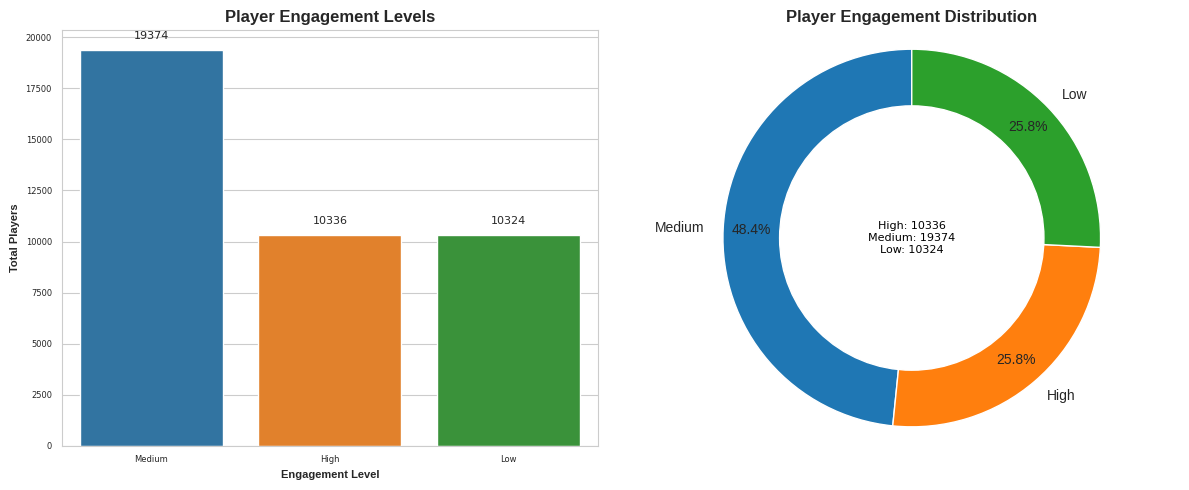

In [12]:
# Define custom colors
palette_features = ['#1f77b4', '#ff7f0e', '#2ca02c']

# Set a clean background with gridlines
sns.set_style('whitegrid')  # Sets the background to white with gridlines

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns

# Plot countplot on the first subplot
sns.countplot(data=df, x='EngagementLevel', palette=palette_features, hue='EngagementLevel', ax=axes[0], legend=False)
axes[0].set_title('Player Engagement Levels', fontsize=12, fontweight='bold', fontname='Liberation Sans', ha='center')
axes[0].set_xlabel('Engagement Level', fontsize=8, fontweight='bold', fontname='Liberation Sans')
axes[0].set_ylabel('Total Players', fontsize=8, fontweight='bold', fontname='Liberation Sans')
axes[0].tick_params(axis='both', labelsize=6)

# Add labels to the bars
for p in axes[0].patches:
    axes[0].annotate(format(p.get_height(), '.0f'),
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center',
                     xytext=(0, 10),
                     textcoords='offset points',
                     fontsize=8)  # Adjust label font size

# Plot pie chart on the second subplot
engagement_counts = df['EngagementLevel'].value_counts()
engagement_distribution = df['EngagementLevel'].value_counts(normalize=True) * 100

axes[1].pie(engagement_distribution, labels=engagement_distribution.index,
            autopct='%1.1f%%', colors=palette_features, pctdistance=0.85, startangle=90,
            textprops={'fontname': 'Liberation Sans'})  # Set fontname for labels in pie chart

centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)
total_counts = f"High: {engagement_counts['High']}\nMedium: {engagement_counts['Medium']}\nLow: {engagement_counts['Low']}"
axes[1].text(x=0, y=0, s=total_counts, horizontalalignment='center', verticalalignment='center', fontsize=8, color='black')  # Adjust text font size
axes[1].axis('equal')
axes[1].set_title('Player Engagement Distribution', fontsize=12, fontweight='bold', fontname='Liberation Sans', ha='center')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

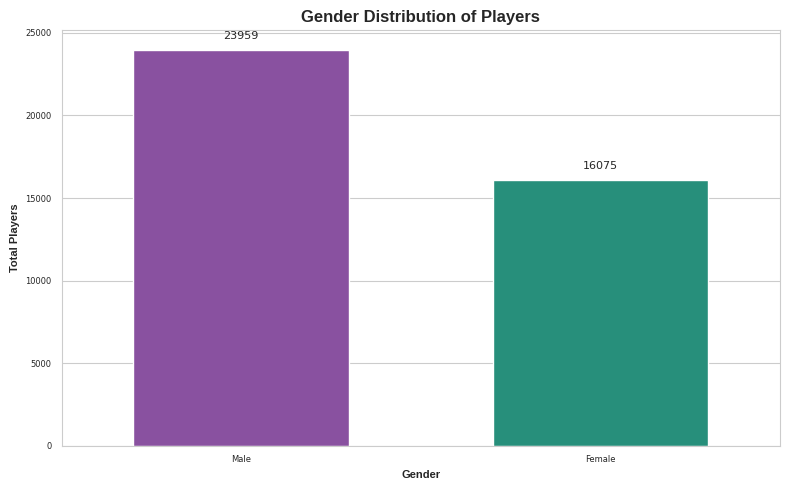

In [13]:
# Define custom colors for Gender plot
gender_palette = ['#8e44ad', '#16a085']  # Purple and Teal for Male and Female

# Set a clean background with gridlines
sns.set_style('whitegrid')  # Sets the background to white with gridlines

# Create a figure with one subplot
fig, ax = plt.subplots(figsize=(8, 5))  # 1 row, 1 column for Gender countplot

# Plot countplot for Gender distribution with narrower bars
sns.countplot(
    data=df,
    x='Gender',
    palette=gender_palette,
    hue='Gender',
    ax=ax,
    legend=False,
    width=0.6  # Decrease the width of the bars; adjust value as needed
)

# Set plot titles and labels
ax.set_title('Gender Distribution of Players', fontsize=12, fontweight='bold', fontname='Liberation Sans', ha='center')
ax.set_xlabel('Gender', fontsize=8, fontweight='bold', fontname='Liberation Sans')
ax.set_ylabel('Total Players', fontsize=8, fontweight='bold', fontname='Liberation Sans')
ax.tick_params(axis='both', labelsize=6)

# Add labels to the bars
for p in ax.patches:
    ax.annotate(
        format(p.get_height(), '.0f'),
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center',
        xytext=(0, 10),
        textcoords='offset points',
        fontsize=8  # Adjust label font size
    )

# Customize layout
plt.tight_layout()

# Show the plot
plt.show()

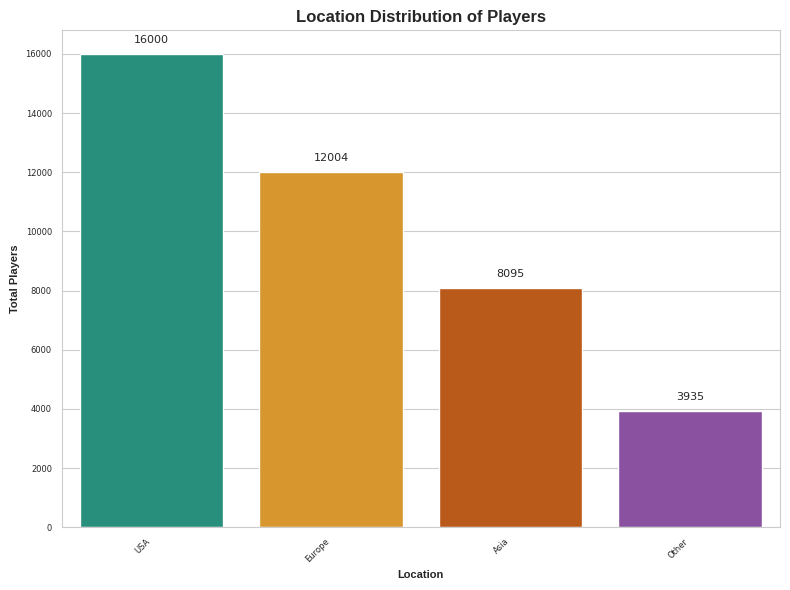

In [14]:

# Define custom colors for Location plot (adjust number of colors to match your data)
location_palette = ['#8e44ad', '#16a085', '#f39c12', '#d35400']  # Adjust the number of colors to match unique locations

# Set a clean background with gridlines
sns.set_style('whitegrid')  # Sets the background to white with gridlines

# Create a figure with one subplot
fig, ax = plt.subplots(figsize=(8, 6))  # Adjust size if needed for readability

# Plot countplot for Location distribution with hue set to Location for color assignment
sns.countplot(data=df, x='Location', hue='Location', palette=location_palette, ax=ax, order=df['Location'].value_counts().index, legend=False)
ax.set_title('Location Distribution of Players', fontsize=12, fontweight='bold', fontname='Liberation Sans', ha='center')
ax.set_xlabel('Location', fontsize=8, fontweight='bold', fontname='Liberation Sans')
ax.set_ylabel('Total Players', fontsize=8, fontweight='bold', fontname='Liberation Sans')
ax.tick_params(axis='both', labelsize=6)

# Correctly rotate x-axis labels for readability
plt.xticks(rotation=45, ha='right')

# Add labels to the bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 10),
                textcoords='offset points',
                fontsize=8)  # Adjust label font size

# Customize layout
plt.tight_layout()

# Show the plot
plt.show()

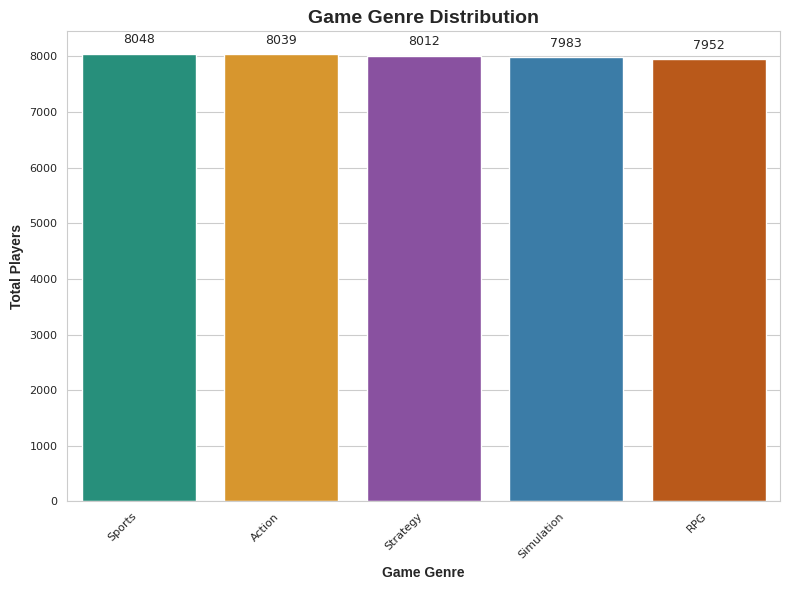

In [15]:
# Automatically adjust the palette to match the number of unique game genres
unique_genres = df['GameGenre'].nunique()  # Count the unique genres in your data
game_genre_palette = ['#8e44ad', '#16a085', '#f39c12', '#d35400', '#2980b9', '#c0392b'][:unique_genres]  # Slice the palette to fit the number of genres

# Set a clean background with gridlines
sns.set_style('whitegrid')  # Set the style to whitegrid for a clean look

# Create a figure with one subplot for Game Genre distribution
fig, ax = plt.subplots(figsize=(8, 6))  # Adjust size for readability

# Plot countplot for Game Genre distribution
sns.countplot(
    data=df,
    x='GameGenre',
    hue='GameGenre',
    palette=game_genre_palette,
    ax=ax,
    order=df['GameGenre'].value_counts().index,
    legend=False
)

# Customize plot appearance
ax.set_title('Game Genre Distribution', fontsize=14, fontweight='bold', fontname='Liberation Sans', ha='center')
ax.set_xlabel('Game Genre', fontsize=10, fontweight='bold', fontname='Liberation Sans')
ax.set_ylabel('Total Players', fontsize=10, fontweight='bold', fontname='Liberation Sans')
ax.tick_params(axis='both', labelsize=8)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add labels to the bars
for p in ax.patches:
    ax.annotate(
        format(p.get_height(), '.0f'),
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 10),
        textcoords='offset points',
        fontsize=9
    )  # Adjust label font size

# Adjust layout for better appearance
plt.tight_layout()

# Show the plot
plt.show()

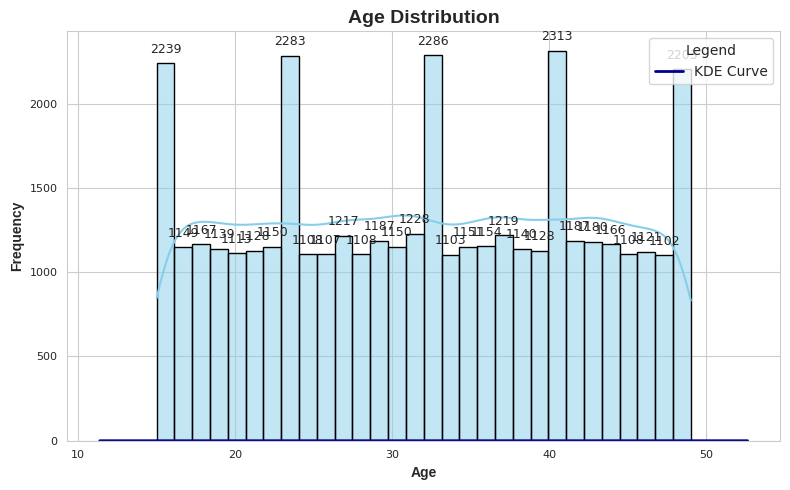

In [16]:
# Set a clean background with gridlines
sns.set_style('whitegrid')  # Set the style to whitegrid for a clean look

# Create a figure with one subplot for Age distribution
fig, ax = plt.subplots(figsize=(8, 5))  # Adjust size for readability

# Plot histogram with KDE for Age distribution
sns.histplot(
    df['Age'],
    kde=True,
    color='skyblue',
    ax=ax,
    bins=30,  # Adjust number of bins if necessary
    edgecolor='black'  # Add edge color to bars for better distinction
)

# Customize plot appearance
ax.set_title('Age Distribution', fontsize=14, fontweight='bold', fontname='Liberation Sans', ha='center')
ax.set_xlabel('Age', fontsize=10, fontweight='bold', fontname='Liberation Sans')
ax.set_ylabel('Frequency', fontsize=10, fontweight='bold', fontname='Liberation Sans')
ax.tick_params(axis='both', labelsize=8)

# Add labels to the bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # Avoid annotating bars with height 0
        ax.annotate(
            format(height, '.0f'),
            (p.get_x() + p.get_width() / 2., height),
            ha='center',
            va='center',
            xytext=(0, 10),
            textcoords='offset points',
            fontsize=9
        )  # Adjust label font size

# Add KDE curve manually to ensure visibility
sns.kdeplot(
    df['Age'],
    ax=ax,
    color='darkblue',
    lw=2,  # Line width for KDE curve
    label='KDE Curve'
)

# Add a legend for the KDE curve
ax.legend(title='Legend', fontsize=10)

# Adjust layout for better appearance
plt.tight_layout()

# Show the plot
plt.show()

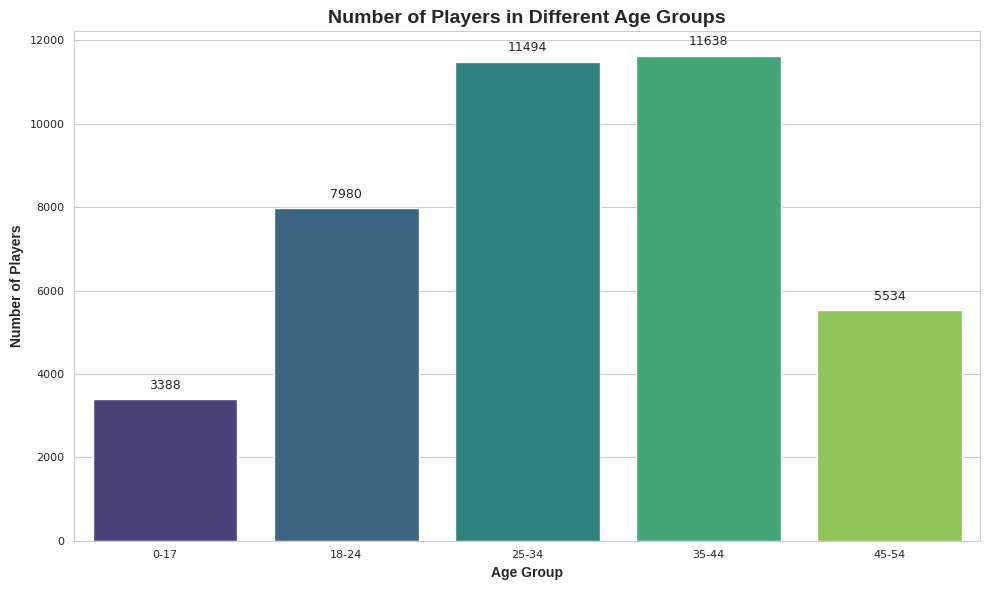

In [17]:
# Assuming 'df' is your DataFrame

# Define age bins and labels
age_bins = [0, 18, 25, 35, 45, 55]  # Adjust bins as needed
age_labels = ['0-17', '18-24', '25-34', '35-44', '45-54']  # Labels for the bins

# Create a new column 'AgeGroup' based on age bins
df['AgeGroup'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)

# Set a clean background with gridlines
sns.set_style('whitegrid')  # Set the style to whitegrid for a clean look

# Create a figure with one subplot for Age Group distribution
fig, ax = plt.subplots(figsize=(10, 6))  # Adjust size for readability

# Plot countplot for Age Group distribution
sns.countplot(
    data=df,
    x='AgeGroup',
    hue='AgeGroup',  # Assign 'AgeGroup' to 'hue' to avoid the warning
    palette='viridis',  # Use a color palette
    ax=ax,
    legend=False  # Disable the legend to match the original plot style
)

# Customize plot appearance
ax.set_title('Number of Players in Different Age Groups', fontsize=14, fontweight='bold', fontname='Liberation Sans', ha='center')
ax.set_xlabel('Age Group', fontsize=10, fontweight='bold', fontname='Liberation Sans')
ax.set_ylabel('Number of Players', fontsize=10, fontweight='bold', fontname='Liberation Sans')
ax.tick_params(axis='both', labelsize=8)

# Add labels to the bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # Avoid annotating bars with height 0
        ax.annotate(
            format(height, '.0f'),
            (p.get_x() + p.get_width() / 2., height),
            ha='center',
            va='center',
            xytext=(0, 10),
            textcoords='offset points',
            fontsize=9
        )  # Adjust label font size

# Adjust layout for better appearance
plt.tight_layout()

# Show the plot
plt.show()

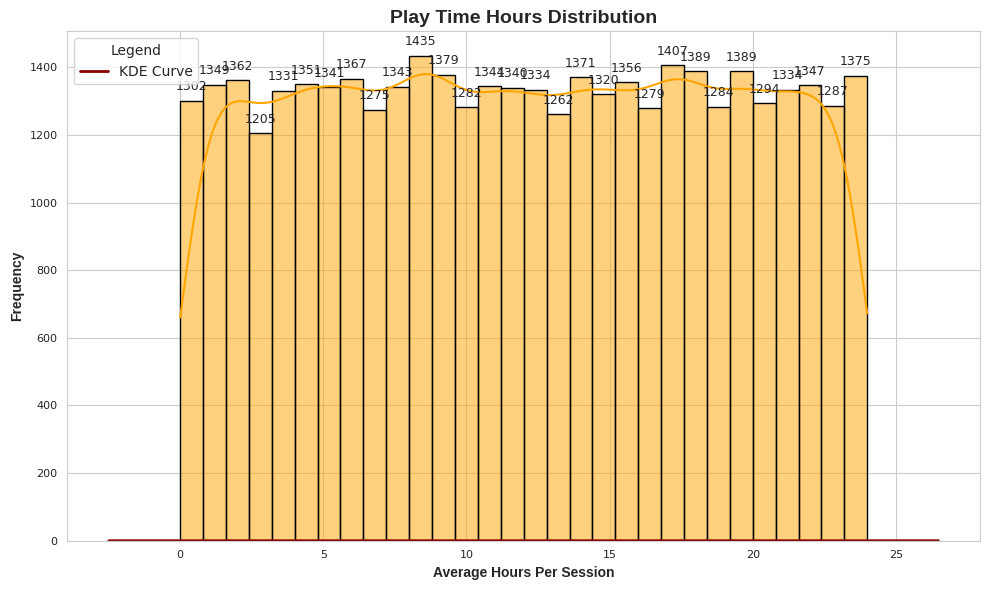

In [18]:
# Assuming 'df' is your DataFrame

# Set a clean background with gridlines
sns.set_style('whitegrid')  # Set the style to whitegrid for a clean look

# Create a figure with one subplot for Play Time Hours distribution
fig, ax = plt.subplots(figsize=(10, 6))  # Adjust size for readability

# Plot histogram with KDE for Play Time Hours distribution
sns.histplot(
    df['PlayTimeHours'],
    kde=True,
    color='orange',
    ax=ax,
    bins=30,  # Adjust number of bins if necessary
    edgecolor='black'  # Add edge color to bars for better distinction
)

# Add KDE curve manually to ensure visibility
sns.kdeplot(
    df['PlayTimeHours'],
    ax=ax,
    color='darkred',
    lw=2,  # Line width for KDE curve
    label='KDE Curve'
)

# Customize plot appearance
ax.set_title('Play Time Hours Distribution', fontsize=14, fontweight='bold', fontname='Liberation Sans', ha='center')
ax.set_xlabel('Average Hours Per Session', fontsize=10, fontweight='bold', fontname='Liberation Sans')
ax.set_ylabel('Frequency', fontsize=10, fontweight='bold', fontname='Liberation Sans')
ax.tick_params(axis='both', labelsize=8)

# Add labels to the bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # Avoid annotating bars with height 0
        ax.annotate(
            format(height, '.0f'),
            (p.get_x() + p.get_width() / 2., height),
            ha='center',
            va='center',
            xytext=(0, 10),
            textcoords='offset points',
            fontsize=9
        )  # Adjust label font size

# Add a legend for the KDE curve
ax.legend(title='Legend', fontsize=10)

# Adjust layout for better appearance
plt.tight_layout()

# Show the plot
plt.show()

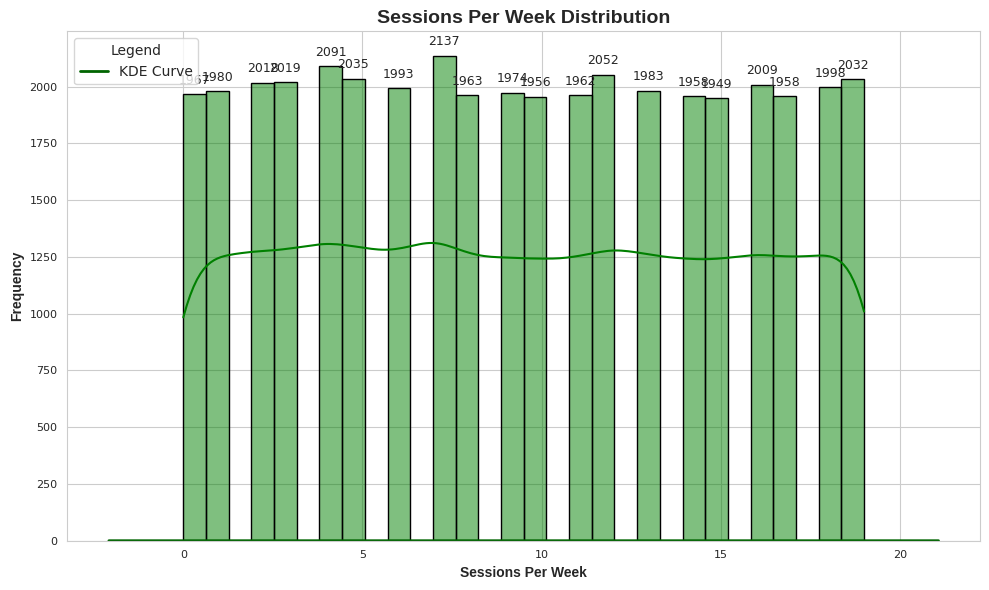

In [19]:
# Set a clean background with gridlines
sns.set_style('whitegrid')  # Set the style to whitegrid for a clean look

# Create a figure with one subplot for Sessions Per Week distribution
fig, ax = plt.subplots(figsize=(10, 6))  # Adjust size for readability

# Plot histogram with KDE for Sessions Per Week distribution
sns.histplot(
    df['SessionsPerWeek'],
    kde=True,
    color='green',
    ax=ax,
    bins=30,  # Adjust number of bins if necessary
    edgecolor='black'  # Add edge color to bars for better distinction
)

# Add KDE curve manually to ensure visibility
sns.kdeplot(
    df['SessionsPerWeek'],
    ax=ax,
    color='darkgreen',
    lw=2,  # Line width for KDE curve
    label='KDE Curve'
)

# Customize plot appearance
ax.set_title('Sessions Per Week Distribution', fontsize=14, fontweight='bold', fontname='Liberation Sans', ha='center')
ax.set_xlabel('Sessions Per Week', fontsize=10, fontweight='bold', fontname='Liberation Sans')
ax.set_ylabel('Frequency', fontsize=10, fontweight='bold', fontname='Liberation Sans')
ax.tick_params(axis='both', labelsize=8)

# Add labels to the bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # Avoid annotating bars with height 0
        ax.annotate(
            format(height, '.0f'),
            (p.get_x() + p.get_width() / 2., height),
            ha='center',
            va='center',
            xytext=(0, 10),
            textcoords='offset points',
            fontsize=9
        )  # Adjust label font size

# Add a legend for the KDE curve
ax.legend(title='Legend', fontsize=10)

# Adjust layout for better appearance
plt.tight_layout()

# Show the plot
plt.show()

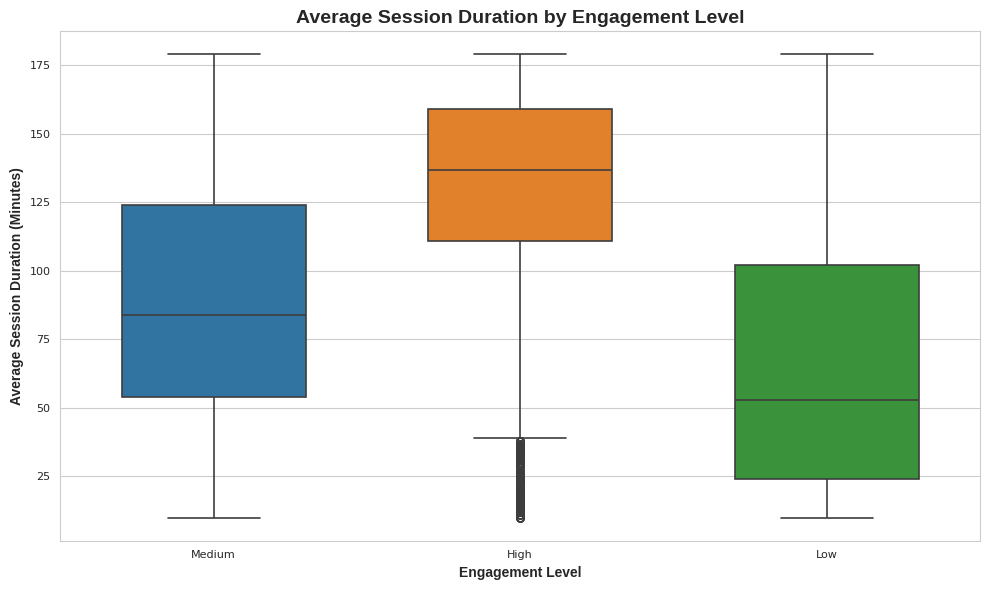

In [20]:
# Set a clean background with gridlines
sns.set_style('whitegrid')  # Set the style to whitegrid for a clean look

# Create a figure with one subplot for Average Session Duration by Engagement Level
plt.figure(figsize=(10, 6))  # Adjust size for readability

# Plot boxplot for Average Session Duration by Engagement Level
sns.boxplot(
    data=df,
    x='EngagementLevel',
    y='AvgSessionDurationMinutes',
    hue='EngagementLevel',  # Use 'hue' to match the palette
    palette=['#1f77b4', '#ff7f0e', '#2ca02c'],  # Color palette for different engagement levels
    linewidth=1.2,  # Adjust the line width of the box edges
    fliersize=5,  # Adjust the size of the outliers
    width=0.6  # Adjust the width of the boxes
)

# Customize plot appearance
plt.title('Average Session Duration by Engagement Level', fontsize=14, fontweight='bold', fontname='Liberation Sans', ha='center')
plt.xlabel('Engagement Level', fontsize=10, fontweight='bold', fontname='Liberation Sans')
plt.ylabel('Average Session Duration (Minutes)', fontsize=10, fontweight='bold', fontname='Liberation Sans')
plt.xticks(fontsize=8)  # Adjust the size of x-axis labels
plt.yticks(fontsize=8)  # Adjust the size of y-axis labels

# Adjust layout for better appearance
plt.tight_layout()

# Show the plot
plt.show()

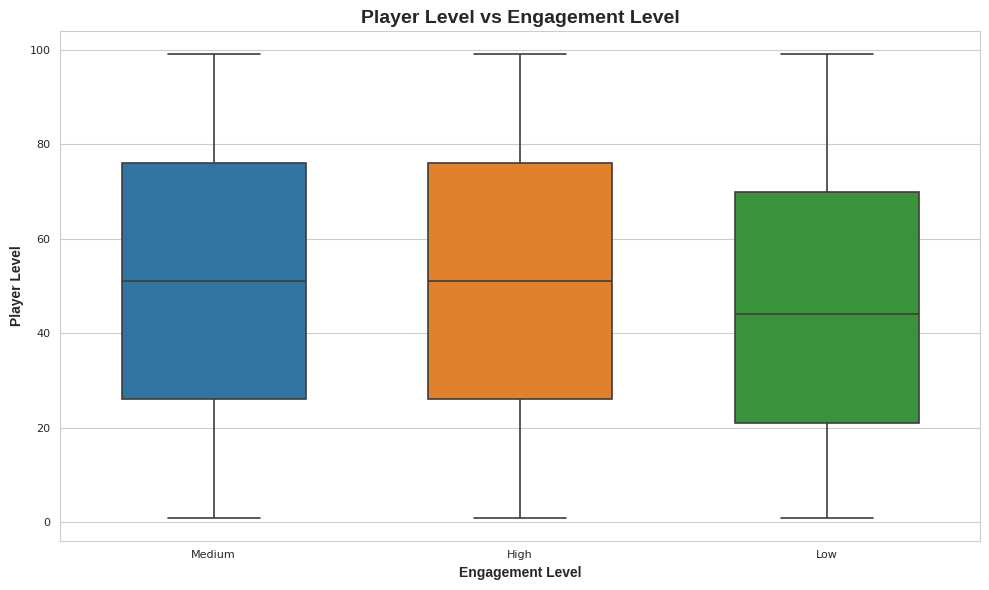

In [21]:
# Set a clean background with gridlines
sns.set_style('whitegrid')  # Set the style to whitegrid for a clean look

# Create a figure with one subplot for Player Level vs Engagement Level
plt.figure(figsize=(10, 6))  # Adjust size for readability

# Plot boxplot for Player Level vs Engagement Level
sns.boxplot(
    data=df,
    x='EngagementLevel',
    y='PlayerLevel',
    hue='EngagementLevel',  # Use 'hue' to match the palette
    palette=['#1f77b4', '#ff7f0e', '#2ca02c'],  # Color palette for different engagement levels
    linewidth=1.2,  # Adjust the line width of the box edges
    fliersize=5,  # Adjust the size of the outliers
    width=0.6  # Adjust the width of the boxes
)

# Customize plot appearance
plt.title('Player Level vs Engagement Level', fontsize=14, fontweight='bold', fontname='Liberation Sans', ha='center')
plt.xlabel('Engagement Level', fontsize=10, fontweight='bold', fontname='Liberation Sans')
plt.ylabel('Player Level', fontsize=10, fontweight='bold', fontname='Liberation Sans')
plt.xticks(fontsize=8)  # Adjust the size of x-axis labels
plt.yticks(fontsize=8)  # Adjust the size of y-axis labels

# Adjust layout for better appearance
plt.tight_layout()

# Show the plot
plt.show()

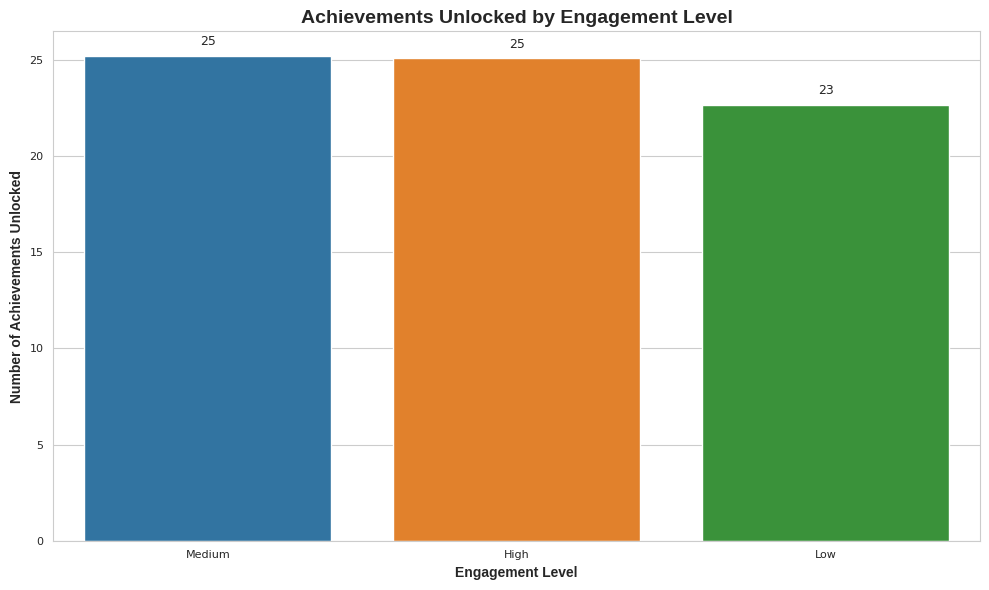

In [22]:
# Set a clean background with gridlines
sns.set_style('whitegrid')  # Set the style to whitegrid for a clean look

# Create a figure with one subplot for Achievements Unlocked by Engagement Level
plt.figure(figsize=(10, 6))  # Adjust size for readability

# Plot barplot for Achievements Unlocked by Engagement Level
sns.barplot(
    data=df,
    x='EngagementLevel',
    y='AchievementsUnlocked',
    hue='EngagementLevel',  # Use 'hue' to match the palette
    palette=['#1f77b4', '#ff7f0e', '#2ca02c'],  # Color palette for different engagement levels
    errorbar=None  # Disable error bars (replaces `ci=None`)
)

# Customize plot appearance
plt.title('Achievements Unlocked by Engagement Level', fontsize=14, fontweight='bold', fontname='Liberation Sans', ha='center')
plt.xlabel('Engagement Level', fontsize=10, fontweight='bold', fontname='Liberation Sans')
plt.ylabel('Number of Achievements Unlocked', fontsize=10, fontweight='bold', fontname='Liberation Sans')
plt.xticks(fontsize=8)  # Adjust the size of x-axis labels
plt.yticks(fontsize=8)  # Adjust the size of y-axis labels

# Add labels to the bars
for p in plt.gca().patches:
    plt.gca().annotate(
        format(p.get_height(), '.0f'),
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 10),
        textcoords='offset points',
        fontsize=9
    )  # Adjust label font size

# Adjust layout for better appearance
plt.tight_layout()

# Show the plot
plt.show()

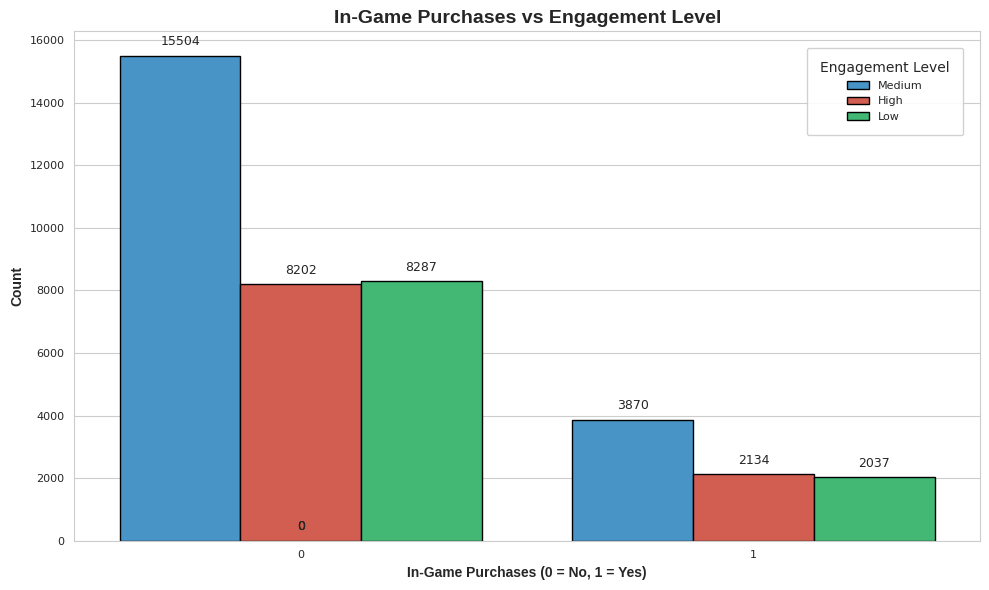

In [23]:
# Define a custom color palette
custom_palette = ['#3498db', '#e74c3c', '#2ecc71']  # Replace with your preferred colors

# Set a clean background with gridlines
sns.set_style('whitegrid')  # Set the style to whitegrid for a clean look

# Create a figure with one subplot for In-Game Purchases vs Engagement Level
plt.figure(figsize=(10, 6))  # Adjust size for readability

# Plot countplot for In-Game Purchases vs Engagement Level
ax = sns.countplot(
    data=df,
    x='InGamePurchases',
    hue='EngagementLevel',  # Use 'hue' to differentiate engagement levels
    palette=custom_palette,  # Apply custom color palette
    edgecolor='black'  # Add edge color to bars for better visibility
)

# Customize plot appearance
plt.title('In-Game Purchases vs Engagement Level', fontsize=14, fontweight='bold', fontname='Liberation Sans', ha='center')
plt.xlabel('In-Game Purchases (0 = No, 1 = Yes)', fontsize=10, fontweight='bold', fontname='Liberation Sans')
plt.ylabel('Count', fontsize=10, fontweight='bold', fontname='Liberation Sans')
plt.xticks(fontsize=8)  # Adjust the size of x-axis labels
plt.yticks(fontsize=8)  # Adjust the size of y-axis labels

# Customize legend
plt.legend(
    title='Engagement Level',
    title_fontsize='10',  # Set font size for the legend title
    fontsize='8',  # Set font size for the legend labels
    loc='upper right',  # Adjust location if needed
    frameon=True,  # Set to False if you prefer no legend frame
    framealpha=0.9,  # Set frame transparency
    borderpad=1.2,  # Padding between the legend border and content
    borderaxespad=1.5  # Padding between the legend border and axes
)

# Add labels to the bars
for p in plt.gca().patches:
    plt.gca().annotate(
        format(p.get_height(), '.0f'),
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 10),
        textcoords='offset points',
        fontsize=9
    )  # Adjust label font size

# Adjust layout for better appearance
plt.tight_layout()

# Show the plot
plt.show()

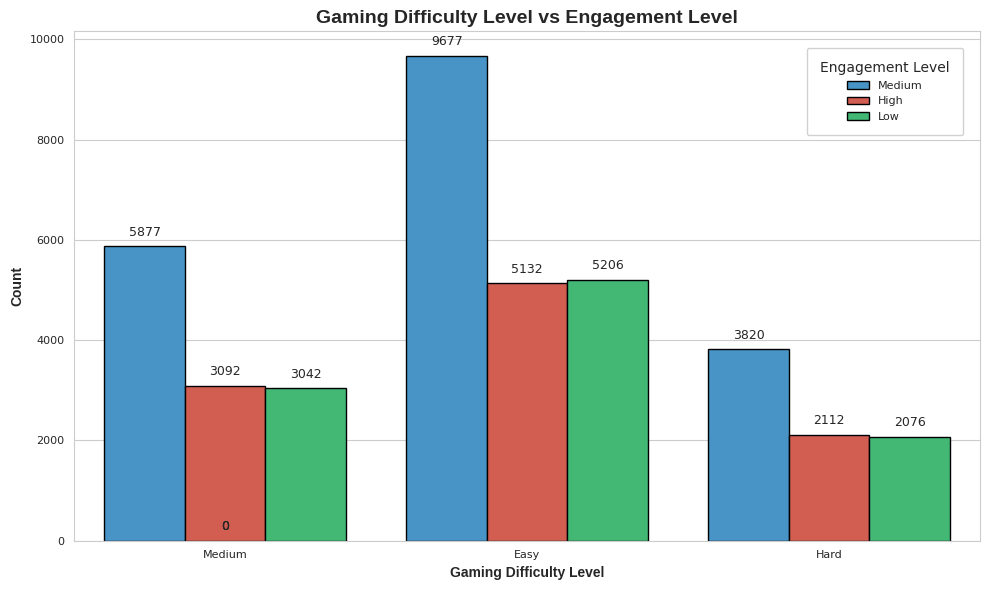

In [24]:
# Create a figure with one subplot for Gaming Difficulty Level vs Engagement Level
plt.figure(figsize=(10, 6))  # Adjust size for readability

# Plot countplot for Gaming Difficulty Level vs Engagement Level
ax = sns.countplot(
    data=df,
    x='GameDifficulty',  # Replace with the column name for gaming difficulty level
    hue='EngagementLevel',  # Use 'hue' to differentiate engagement levels
    palette=custom_palette,  # Apply custom color palette
    edgecolor='black'  # Add edge color to bars for better visibility
)

# Customize plot appearance
plt.title('Gaming Difficulty Level vs Engagement Level', fontsize=14, fontweight='bold', fontname='Liberation Sans', ha='center')
plt.xlabel('Gaming Difficulty Level', fontsize=10, fontweight='bold', fontname='Liberation Sans')
plt.ylabel('Count', fontsize=10, fontweight='bold', fontname='Liberation Sans')
plt.xticks(fontsize=8)  # Adjust the size of x-axis labels
plt.yticks(fontsize=8)  # Adjust the size of y-axis labels

# Customize legend
plt.legend(
    title='Engagement Level',
    title_fontsize='10',  # Set font size for the legend title
    fontsize='8',  # Set font size for the legend labels
    loc='upper right',  # Adjust location if needed
    frameon=True,  # Set to False if you prefer no legend frame
    framealpha=0.9,  # Set frame transparency
    borderpad=1.2,  # Padding between the legend border and content
    borderaxespad=1.5  # Padding between the legend border and axes
)

# Add labels to the bars
for p in plt.gca().patches:
    plt.gca().annotate(
        format(p.get_height(), '.0f'),
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 10),
        textcoords='offset points',
        fontsize=9
    )  # Adjust label font size

# Adjust layout for better appearance
plt.tight_layout()

# Show the plot
plt.show()

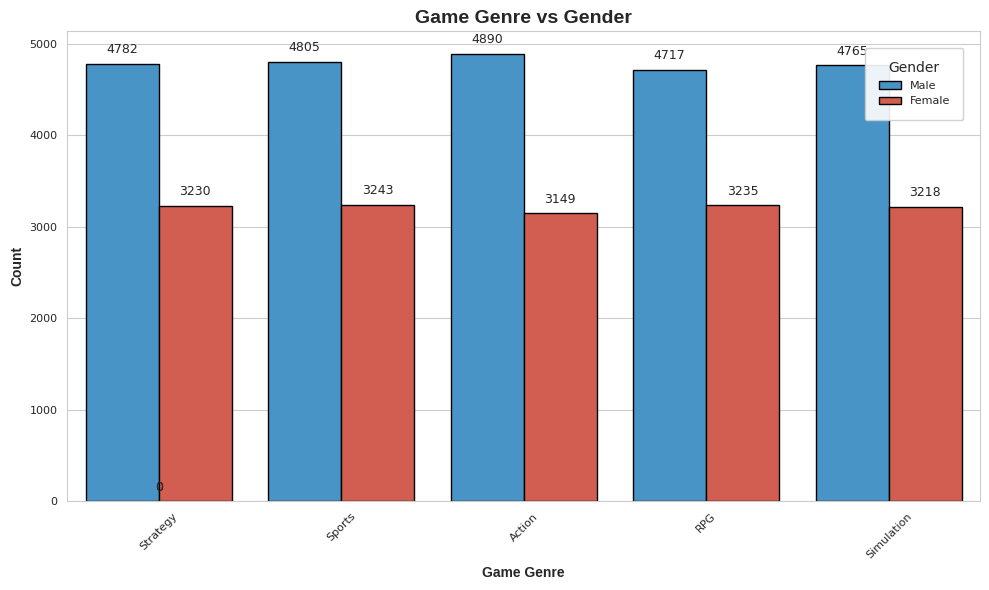

In [25]:
# Define a custom palette with only two colors for Gender
custom_palette_gender = ['#3498db', '#e74c3c']  # Two colors: one for each gender

# Create a figure with one subplot for Game Genre vs Gender
plt.figure(figsize=(10, 6))

# Plot countplot for Game Genre vs Gender
ax = sns.countplot(
    data=df,
    x='GameGenre',
    hue='Gender',
    palette=custom_palette_gender,  # Use the updated palette with two colors
    edgecolor='black'
)

# Customize plot appearance (same as before)
plt.title('Game Genre vs Gender', fontsize=14, fontweight='bold', fontname='Liberation Sans', ha='center')
plt.xlabel('Game Genre', fontsize=10, fontweight='bold', fontname='Liberation Sans')
plt.ylabel('Count', fontsize=10, fontweight='bold', fontname='Liberation Sans')
plt.xticks(rotation=45, fontsize=8)
plt.yticks(fontsize=8)

plt.legend(
    title='Gender',
    title_fontsize='10',
    fontsize='8',
    loc='upper right',
    frameon=True,
    framealpha=0.9,
    borderpad=1.2,
    borderaxespad=1.5
)

# Add labels to the bars
for p in plt.gca().patches:
    plt.gca().annotate(
        format(p.get_height(), '.0f'),
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 10),
        textcoords='offset points',
        fontsize=9
    )

plt.tight_layout()
plt.show()

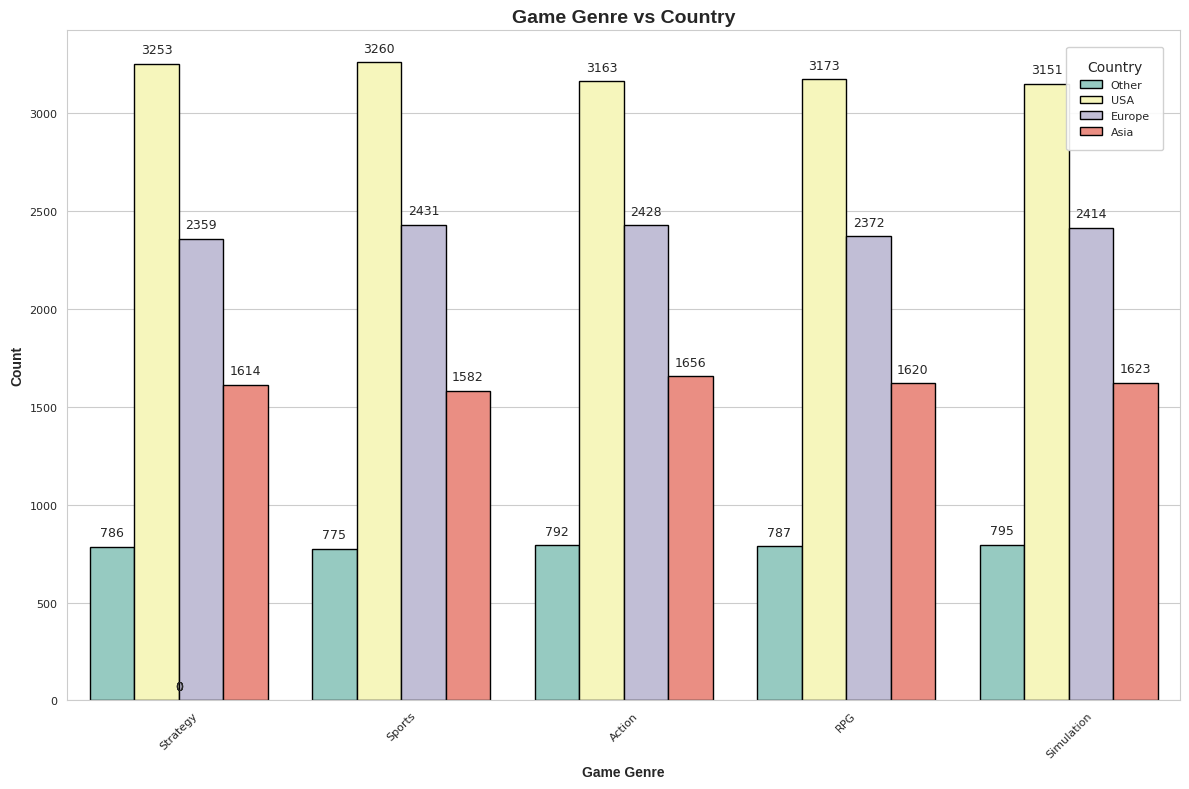

In [26]:
# Create a figure with one subplot for Game Genre vs Country
plt.figure(figsize=(12, 8))  # Increase the figure size for better readability if there are many countries

# Plot countplot for Game Genre vs Country
ax = sns.countplot(
    data=df,
    x='GameGenre',  # Game Genre on the x-axis
    hue='Location',  # Differentiate by Country
    palette='Set3',  # Use a built-in color palette that can handle many categories
    edgecolor='black'
)

# Customize plot appearance
plt.title('Game Genre vs Country', fontsize=14, fontweight='bold', fontname='Liberation Sans', ha='center')
plt.xlabel('Game Genre', fontsize=10, fontweight='bold', fontname='Liberation Sans')
plt.ylabel('Count', fontsize=10, fontweight='bold', fontname='Liberation Sans')
plt.xticks(rotation=45, fontsize=8)  # Rotate x-axis labels if necessary
plt.yticks(fontsize=8)  # Adjust the size of y-axis labels

# Customize legend
plt.legend(
    title='Country',
    title_fontsize='10',
    fontsize='8',
    loc='upper right',  # Adjust location if needed
    frameon=True,
    framealpha=0.9,
    borderpad=1.2,
    borderaxespad=1.5
)

# Add labels to the bars
for p in plt.gca().patches:
    plt.gca().annotate(
        format(p.get_height(), '.0f'),
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 10),
        textcoords='offset points',
        fontsize=9
    )

# Adjust layout for better appearance
plt.tight_layout()

# Show the plot
plt.show()

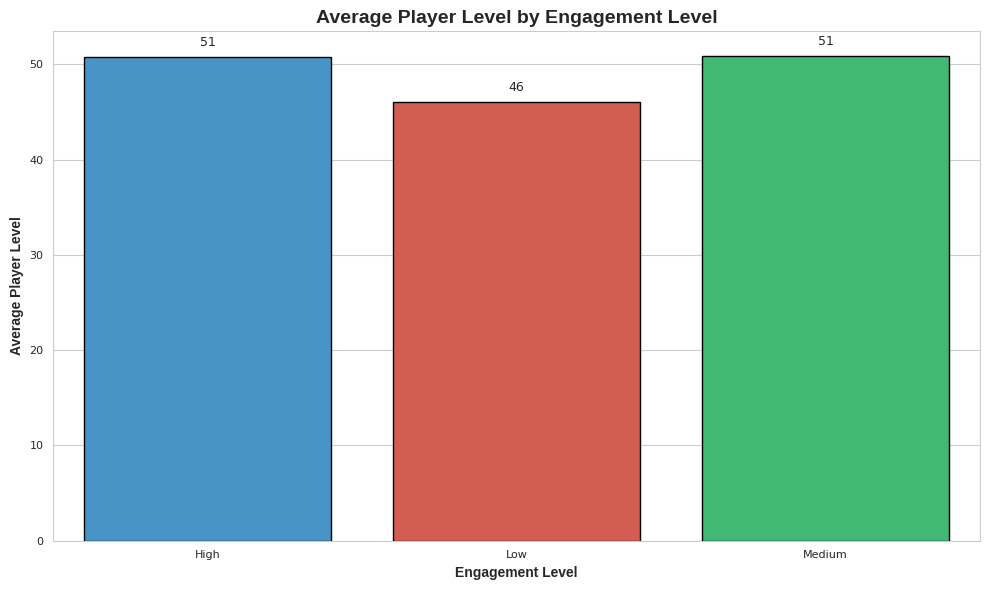

In [27]:
# Group by Engagement Level and find the maximum player level
max_player_level = df.groupby('EngagementLevel')['PlayerLevel'].mean().reset_index()

# Create a figure with one subplot for Maximum Player Level by Engagement Level
plt.figure(figsize=(10, 6))

# Plot barplot for Maximum Player Level by Engagement Level
ax = sns.barplot(
    data=max_player_level,
    x='EngagementLevel',  # Engagement Level on x-axis
    y='PlayerLevel',  # Maximum Player Level on y-axis
    palette=custom_palette,  # Apply custom color palette
    edgecolor='black'
)

# Customize plot appearance
plt.title('Average Player Level by Engagement Level', fontsize=14, fontweight='bold', fontname='Liberation Sans', ha='center')
plt.xlabel('Engagement Level', fontsize=10, fontweight='bold', fontname='Liberation Sans')
plt.ylabel('Average Player Level', fontsize=10, fontweight='bold', fontname='Liberation Sans')
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

# Add labels to the bars
for p in ax.patches:
    ax.annotate(
        format(p.get_height(), '.0f'),
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 10),
        textcoords='offset points',
        fontsize=9
    )

# Adjust layout for better appearance
plt.tight_layout()

# Show the plot
plt.show()

In [28]:
gender_country_data = df.join(pd.get_dummies(df.Gender)).drop(['Gender'], axis=1)
gender_country_data = df.join(pd.get_dummies(df.Location)).drop(['Location'], axis=1)
gender_country_data = df.join(pd.get_dummies(df.EngagementLevel)).drop(['EngagementLevel'], axis=1)

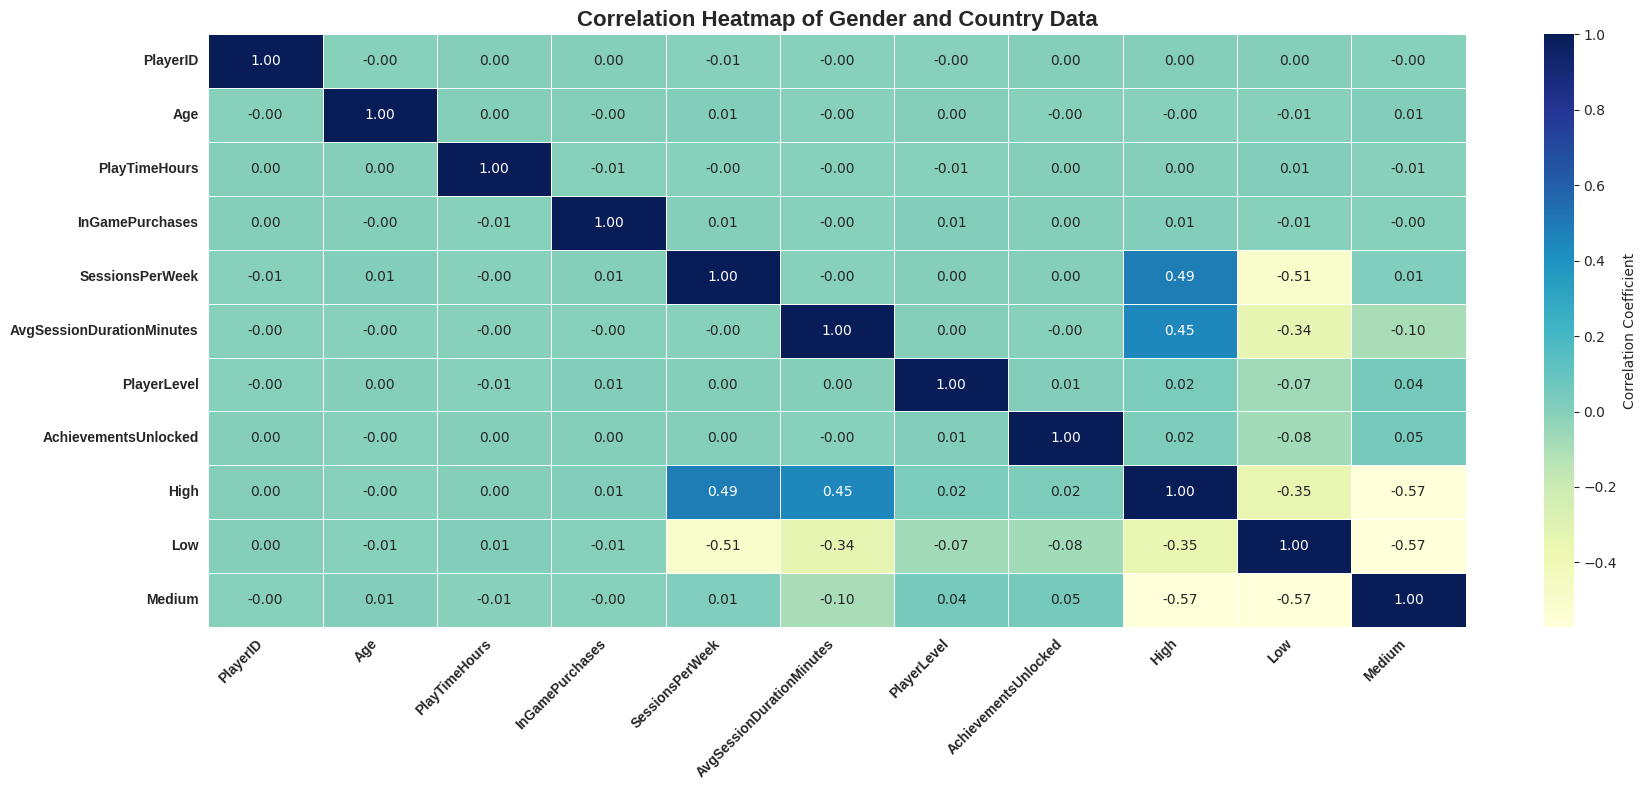

In [29]:
# Create a figure for the heatmap with larger size for better readability
plt.figure(figsize=(18, 8))

# Generate a heatmap for the correlation matrix of numeric data
sns.heatmap(
    gender_country_data.corr(numeric_only=True),  # Correlation matrix of numeric columns
    annot=True,  # Show correlation coefficients on the heatmap
    fmt='.2f',  # Format the annotation to 2 decimal places
    cmap='YlGnBu',  # Color map (yellow-green-blue)
    linewidths=0.5,  # Add lines between the cells
    linecolor='white',  # Line color for the grid
    cbar_kws={'label': 'Correlation Coefficient'},  # Add a label to the color bar
    square=False  # Set to False if you don't want square cells
)

# Add a title to the heatmap
plt.title('Correlation Heatmap of Gender and Country Data', fontsize=16, fontweight='bold', fontname='Liberation Sans')

# Customize the ticks on the x and y axes
plt.xticks(rotation=45, ha='right', fontsize=10, fontweight='bold', fontname='Liberation Sans')  # Rotate x-axis labels
plt.yticks(rotation=0, fontsize=10, fontweight='bold', fontname='Liberation Sans')  # Keep y-axis labels horizontal

# Adjust layout for better fit and appearance
plt.tight_layout()

# Show the heatmap
plt.show()

In [30]:
Game_Genre_data = df.join(pd.get_dummies(df.GameGenre)).drop(['GameGenre'], axis=1)
new_data = df.join(pd.get_dummies(df.EngagementLevel)).drop(['EngagementLevel'], axis=1)

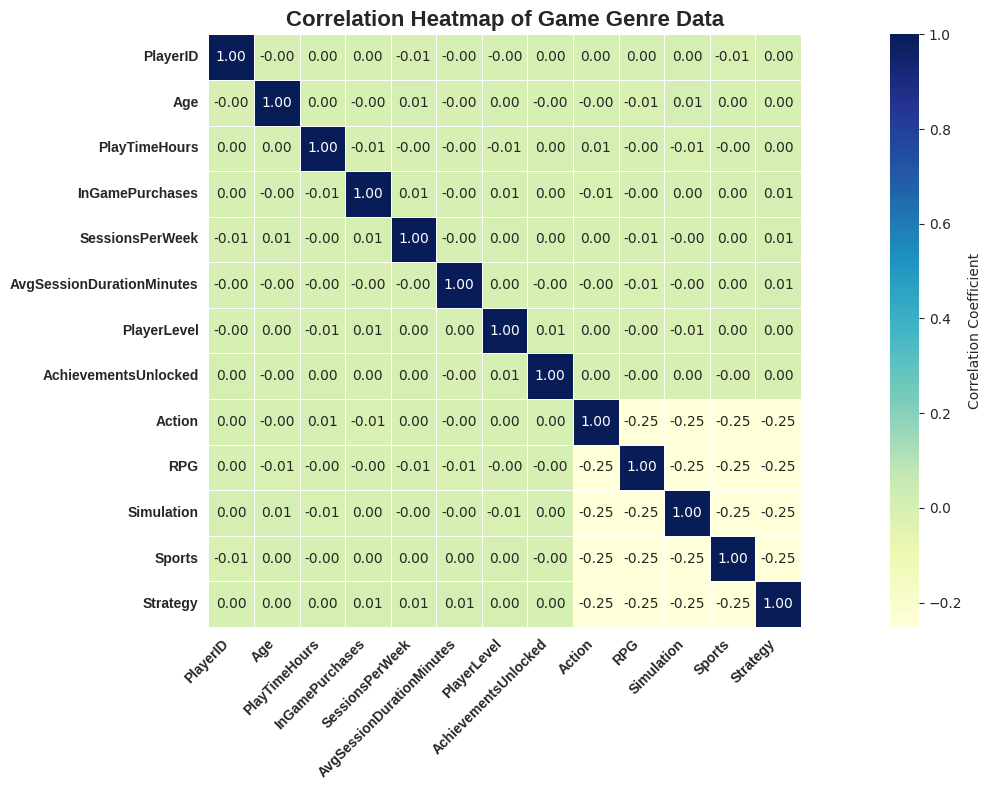

In [31]:
# Create a figure for the heatmap with larger size for better readability
plt.figure(figsize=(18, 8))

# Generate a heatmap for the correlation matrix of numeric data
sns.heatmap(
    Game_Genre_data.corr(numeric_only=True),  # Correlation matrix of numeric columns
    annot=True,  # Display correlation coefficients on the heatmap
    fmt='.2f',  # Format the annotations to 2 decimal places
    cmap='YlGnBu',  # Yellow-green-blue color palette
    linewidths=0.5,  # Add thin lines between cells
    linecolor='white',  # Set the line color between cells to white
    cbar_kws={'label': 'Correlation Coefficient'},  # Add label to the color bar
    square=True  # Make the cells square-shaped
)

# Add a title to the heatmap
plt.title('Correlation Heatmap of Game Genre Data', fontsize=16, fontweight='bold', fontname='Liberation Sans')

# Customize the x and y ticks (labels on the axes)
plt.xticks(rotation=45, ha='right', fontsize=10, fontweight='bold', fontname='Liberation Sans')  # Rotate x-axis labels for readability
plt.yticks(rotation=0, fontsize=10, fontweight='bold', fontname='Liberation Sans')  # Keep y-axis labels horizontal

# Adjust layout to avoid overlap of labels and elements
plt.tight_layout()

# Display the heatmap
plt.show()

In [32]:
new_data['NormPlayTime'] = (df['PlayTimeHours']) - df['PlayTimeHours'].mean()/ df['PlayTimeHours'].std()
new_data['NormSessionsPerWeek'] = (df['SessionsPerWeek'] - df['SessionsPerWeek'].mean())/df['SessionsPerWeek'].std()
new_data['NormAvgSessionDurationMinutes'] = (df['AvgSessionDurationMinutes'] - df['AvgSessionDurationMinutes'].mean()) / df['AvgSessionDurationMinutes'].std()
new_data

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,AgeGroup,High,Low,Medium,NormPlayTime,NormSessionsPerWeek,NormAvgSessionDurationMinutes
0,9000,43,Male,Other,Strategy,16.271,0,Medium,6,108,79,25,35-44,False,False,True,14.532,-0.602,0.269
1,9001,29,Female,USA,Strategy,5.526,0,Medium,5,144,11,10,25-34,False,False,True,3.787,-0.776,1.004
2,9002,22,Female,USA,Sports,8.224,0,Easy,16,142,35,41,18-24,True,False,False,6.485,1.133,0.963
3,9003,35,Male,USA,Action,5.265,1,Easy,9,85,57,47,35-44,False,False,True,3.526,-0.082,-0.200
4,9004,33,Male,Europe,Action,15.532,0,Medium,2,131,95,37,25-34,False,False,True,13.793,-1.296,0.739
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40029,49029,32,Male,USA,Strategy,20.620,0,Easy,4,75,85,14,25-34,False,False,True,18.881,-0.949,-0.404
40030,49030,44,Female,Other,Simulation,13.539,0,Hard,19,114,71,27,35-44,True,False,False,11.800,1.653,0.392
40031,49031,15,Female,USA,RPG,0.240,1,Easy,10,176,29,1,0-17,True,False,False,-1.499,0.092,1.657
40032,49032,34,Male,USA,Sports,14.018,1,Medium,3,128,70,10,25-34,False,False,True,12.279,-1.123,0.678


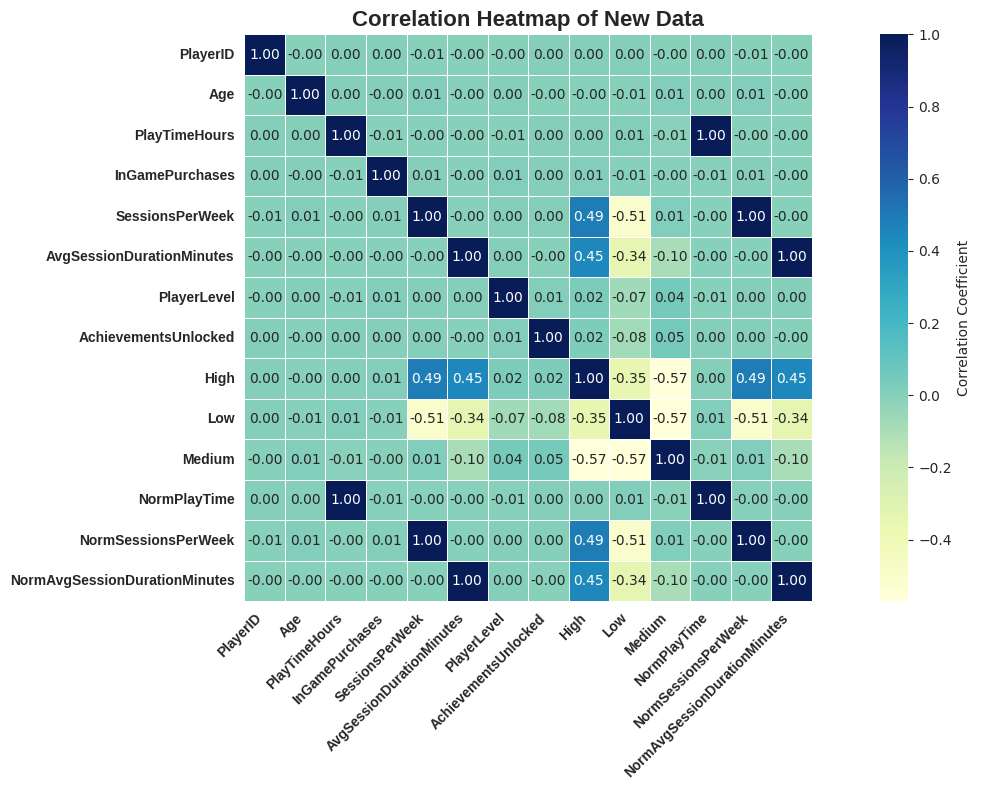

In [33]:
# Create a figure for the heatmap with larger size for better readability
plt.figure(figsize=(14, 8))

# Generate a heatmap for the correlation matrix of the numeric data
sns.heatmap(
    new_data.corr(numeric_only=True),  # Correlation matrix of numeric columns in new_data
    annot=True,  # Display correlation coefficients in the heatmap
    fmt='.2f',  # Format the annotations to 2 decimal places
    cmap='YlGnBu',  # Yellow-Green-Blue color palette for better distinction
    linewidths=0.5,  # Add thin lines between cells for better separation
    linecolor='white',  # Set the line color between cells to white
    cbar_kws={'label': 'Correlation Coefficient'},  # Add label to the color bar for clarity
    square=True  # Ensures the cells are square-shaped
)

# Add a title to the heatmap for context
plt.title('Correlation Heatmap of New Data', fontsize=16, fontweight='bold', fontname='Liberation Sans')

# Customize the x and y ticks (labels on the axes)
plt.xticks(rotation=45, ha='right', fontsize=10, fontweight='bold', fontname='Liberation Sans')  # Rotate x-axis labels for readability
plt.yticks(rotation=0, fontsize=10, fontweight='bold', fontname='Liberation Sans')  # Keep y-axis labels horizontal

# Adjust layout to avoid overlapping of plot elements
plt.tight_layout()

# Display the heatmap
plt.show()

In [34]:
df_cleaned = df.copy()

In [35]:
import missingno as msno

def check_missing_values(df):
    # Check for missing values
    missing_values = df.isnull().sum()

    # Filter out columns with missing values
    missing_values = missing_values[missing_values > 0]

    if missing_values.empty:
        print("No missing values found!")
    else:
        print("Missing Values:")
        print(missing_values)

        # Visualize missing values using missingno
        plt.figure(figsize=(8, 4))  # Adjust the plot size
        msno.matrix(df, figsize=(8, 4), fontsize=8)  # Set the font size
        plt.title('Missing Values Matrix & Analysis (Repurchase Dataset)', fontsize=12, fontname='Liberation Sans', fontweight='bold')
        plt.xticks(fontname='Liberation Sans')  # Set x-axis font to Liberation Sans
        plt.yticks(fontname='Liberation Sans')  # Set y-axis font to Liberation Sans
        plt.show()

# Call the function with your DataFrame
check_missing_values(df_cleaned)

No missing values found!


In [36]:
# Define the numerical columns
numerical_columns = df_cleaned.select_dtypes(include=['float64', 'int64']).columns

# Calculate quartiles and IQR for each numerical feature
Q1 = df_cleaned[numerical_columns].quantile(0.25)
Q3 = df_cleaned[numerical_columns].quantile(0.75)
IQR = Q3 - Q1

# Determine upper and lower bounds for identifying outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers for each numerical feature
outliers = {}
for column in numerical_columns:
    outliers[column] = df_cleaned[(df_cleaned[column] < lower_bound[column]) | (df_cleaned[column] > upper_bound[column])]

# Print outliers for each numerical feature
for column, outlier_df in outliers.items():
    print(f"Outliers in {column}:")
    print(outlier_df)
    print("\n")

Outliers in PlayerID:
Empty DataFrame
Columns: [PlayerID, Age, Gender, Location, GameGenre, PlayTimeHours, InGamePurchases, GameDifficulty, SessionsPerWeek, AvgSessionDurationMinutes, PlayerLevel, AchievementsUnlocked, EngagementLevel, AgeGroup]
Index: []


Outliers in Age:
Empty DataFrame
Columns: [PlayerID, Age, Gender, Location, GameGenre, PlayTimeHours, InGamePurchases, GameDifficulty, SessionsPerWeek, AvgSessionDurationMinutes, PlayerLevel, AchievementsUnlocked, EngagementLevel, AgeGroup]
Index: []


Outliers in PlayTimeHours:
Empty DataFrame
Columns: [PlayerID, Age, Gender, Location, GameGenre, PlayTimeHours, InGamePurchases, GameDifficulty, SessionsPerWeek, AvgSessionDurationMinutes, PlayerLevel, AchievementsUnlocked, EngagementLevel, AgeGroup]
Index: []


Outliers in InGamePurchases:
       PlayerID  Age  Gender Location   GameGenre  PlayTimeHours  \
3          9003   35    Male      USA      Action          5.265   
11         9011   36  Female     Asia  Simulation          5.

In [37]:
def get_column_lists(df_cleaned):
    # List of categorical columns for one-hot encoding
    categorical_columns = [col for col in df_cleaned.columns if df_cleaned.dtypes[col] == 'object']

    # List of numerical columns to standardized data
    numerical_columns = [col for col in df_cleaned.columns if df_cleaned.dtypes[col] != 'object']

    return numerical_columns, categorical_columns

# Call the function with your DataFrame
numerical_cols, categorical_cols = get_column_lists(df_cleaned)

print('Numerical Features are:', numerical_cols)
print('Categorical Features are:', categorical_cols)

Numerical Features are: ['PlayerID', 'Age', 'PlayTimeHours', 'InGamePurchases', 'SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked', 'AgeGroup']
Categorical Features are: ['Gender', 'Location', 'GameGenre', 'GameDifficulty', 'EngagementLevel']


In [38]:
# Removing duplicate rows from the dataset

def drop_duplicates(df):
    # Check for duplicate rows
    duplicate_rows = df[df.duplicated()]

    if duplicate_rows.empty:
        print("No duplicate rows found!")
    else:
        print("Duplicate Rows:")
        print(duplicate_rows)

        # Drop duplicate rows
        df.drop_duplicates(inplace=True)
        print("Duplicate rows have been dropped.")

# Call the function with your DataFrame
drop_duplicates(df_cleaned)

No duplicate rows found!


In [39]:
# Removing irrelevant columns from the dataset

def drop_columns(df_cleaned, columns_to_drop):
    df_cleaned.drop(columns_to_drop, axis=1, inplace=True)
    return df_cleaned

columns_to_drop = ['PlayerID','AgeGroup']

df_cleaned = drop_columns(df_cleaned, columns_to_drop)

In [40]:
df_cleaned.head()

,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,43,Male,Other,Strategy,16.271,0,Medium,6,108,79,25,Medium
1,29,Female,USA,Strategy,5.526,0,Medium,5,144,11,10,Medium
2,22,Female,USA,Sports,8.224,0,Easy,16,142,35,41,High
3,35,Male,USA,Action,5.265,1,Easy,9,85,57,47,Medium
4,33,Male,Europe,Action,15.532,0,Medium,2,131,95,37,Medium


In [41]:
# Create a new column 'IsStressed' with boolean values based on 'GameDifficulty' being "Hard"
df_cleaned["IsStressed"] = np.where(df_cleaned["GameDifficulty"] == "Hard", True, False)

# Map the 'GameDifficulty' categories to numeric values for 'GameDifficultyQuantified'
df_cleaned["GameDifficultyQuantified"] = df_cleaned["GameDifficulty"].map({"Easy": 1, "Medium": 2, "Hard": 3})

df_cleaned = df_cleaned.drop(columns=["GameDifficulty"], axis=1)

# Display the first 10 rows of the updated DataFrame
df_cleaned.head(10)

,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel,IsStressed,GameDifficultyQuantified
0,43,Male,Other,Strategy,16.271,0,6,108,79,25,Medium,False,2
1,29,Female,USA,Strategy,5.526,0,5,144,11,10,Medium,False,2
2,22,Female,USA,Sports,8.224,0,16,142,35,41,High,False,1
3,35,Male,USA,Action,5.265,1,9,85,57,47,Medium,False,1
4,33,Male,Europe,Action,15.532,0,2,131,95,37,Medium,False,2
5,37,Male,Europe,RPG,20.562,0,2,81,74,22,Low,False,1
6,25,Male,USA,Action,9.753,0,1,50,13,2,Low,True,3
7,25,Female,Asia,RPG,4.402,0,10,48,27,23,Medium,False,2
8,38,Female,Europe,Simulation,18.153,0,5,101,23,41,Medium,False,1
9,38,Female,Other,Sports,23.943,0,13,95,99,36,High,False,1


In [42]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold

le = LabelEncoder()
df_cleaned['EngagementLevel'] = le.fit_transform(df_cleaned['EngagementLevel'])

In [43]:
df_cleaned.head()

,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel,IsStressed,GameDifficultyQuantified
0,43,Male,Other,Strategy,16.271,0,6,108,79,25,2,False,2
1,29,Female,USA,Strategy,5.526,0,5,144,11,10,2,False,2
2,22,Female,USA,Sports,8.224,0,16,142,35,41,0,False,1
3,35,Male,USA,Action,5.265,1,9,85,57,47,2,False,1
4,33,Male,Europe,Action,15.532,0,2,131,95,37,2,False,2


In [44]:
# Check unique values in 'IsStressed' to verify
print(df_cleaned['IsStressed'].unique())

[False  True]


In [45]:
# Convert boolean values to integers (False -> 0, True -> 1)
df_cleaned['IsStressed'] = df_cleaned['IsStressed'].astype(int)

# Apply the mapping
df_cleaned['Gender'] = df_cleaned['Gender'].map({'Female': 0, 'Male': 1})

In [46]:
df_cleaned.head()

,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel,IsStressed,GameDifficultyQuantified
0,43,1,Other,Strategy,16.271,0,6,108,79,25,2,0,2
1,29,0,USA,Strategy,5.526,0,5,144,11,10,2,0,2
2,22,0,USA,Sports,8.224,0,16,142,35,41,0,0,1
3,35,1,USA,Action,5.265,1,9,85,57,47,2,0,1
4,33,1,Europe,Action,15.532,0,2,131,95,37,2,0,2


In [47]:
from sklearn.preprocessing import LabelEncoder

# Initialize the LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform the 'GameGenre' column
df_cleaned['GameGenre'] = label_encoder.fit_transform(df_cleaned['GameGenre'])

# Optional: If you want to check the mapping of original categories to labels
category_mapping = dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))
print("Category mapping:", category_mapping)

Category mapping: {'Action': 0, 'RPG': 1, 'Simulation': 2, 'Sports': 3, 'Strategy': 4}


In [48]:
from sklearn.preprocessing import LabelEncoder

# Initialize the LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform the 'Location' column
df_cleaned['Location'] = label_encoder.fit_transform(df_cleaned['Location'])

# Optional: Check the mapping of original categories to labels
category_mapping = dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))
print("Category mapping:", category_mapping)

Category mapping: {'Asia': 0, 'Europe': 1, 'Other': 2, 'USA': 3}


In [49]:
df = df_cleaned

In [50]:
df.head()

,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel,IsStressed,GameDifficultyQuantified
0,43,1,2,4,16.271,0,6,108,79,25,2,0,2
1,29,0,3,4,5.526,0,5,144,11,10,2,0,2
2,22,0,3,3,8.224,0,16,142,35,41,0,0,1
3,35,1,3,0,5.265,1,9,85,57,47,2,0,1
4,33,1,1,0,15.532,0,2,131,95,37,2,0,2


## **Feature Selection**

In [51]:
numerical_col = [i for i in df.columns if df[i].dtype != 'object']

corr_relation = df[numerical_col].corr()

In [52]:
k = 13  # We have Set the desired number as 13 which includes all features to keep

if 'EngagementLevel' in corr_relation.columns:
    features_to_keep = corr_relation['EngagementLevel'].sort_values(ascending=False).index[:k]
else:
    print("Error: 'EngagementLevel' column not found in DataFrame.")

In [53]:
features_to_keep

Index(['EngagementLevel', 'AchievementsUnlocked', 'PlayerLevel', 'Age',
       'Gender', 'Location', 'GameGenre', 'GameDifficultyQuantified',
       'InGamePurchases', 'IsStressed', 'PlayTimeHours', 'SessionsPerWeek',
       'AvgSessionDurationMinutes'],
      dtype='object')

In [54]:
selector = VarianceThreshold(threshold=0.01)  # Adjust threshold as needed
selected_features = selector.fit_transform(df)

In [55]:
df.shape

(40034, 13)

In [56]:
selected_features.shape

(40034, 13)

In [57]:
from sklearn.feature_selection import chi2

chi2_scores, p_values = chi2(df.drop('EngagementLevel', axis=1), df['EngagementLevel'])

In [58]:
print("Length of features_to_keep:", len(features_to_keep))
print("Length of chi2_scores:", len(chi2_scores))
print("Length of p_values:", len(p_values))

Length of features_to_keep: 13
Length of chi2_scores: 12
Length of p_values: 12


In [59]:
# Assuming df is your DataFrame and 'EngagementLevel' is the target variable
target_variable = 'EngagementLevel'

# Identify features (exclude the target variable)
features_to_keep = [col for col in df.columns if col != target_variable]

# Compute chi-squared scores and p-values for the remaining features
chi2_scores, p_values = chi2(df[features_to_keep], df[target_variable])

# Create a DataFrame with valid features and their corresponding scores and p-values
results_df = pd.DataFrame({
    'Feature': features_to_keep,
    'Chi-Squared Score': chi2_scores,
    'P-Value': p_values
})

# Filter out any rows where scores or p-values are NaN (if any)
results_df = results_df.dropna()

# Sort the DataFrame by P-Value for better interpretation
results_df = results_df.sort_values(by='P-Value')

# Display the DataFrame excluding the target variable
results_df = results_df[results_df['Feature'] != target_variable]
results_df

,Feature,Chi-Squared Score,P-Value
6,SessionsPerWeek,51588.583,0.000
7,AvgSessionDurationMinutes,240139.968,0.000
8,PlayerLevel,3540.413,0.000
9,AchievementsUnlocked,1976.664,0.000
4,PlayTimeHours,14.505,0.001
0,Age,9.505,0.009
5,InGamePurchases,2.383,0.304
3,GameGenre,2.039,0.361
10,IsStressed,1.806,0.405
11,GameDifficultyQuantified,0.494,0.781


In [60]:
alpha = 0.05

# Identify the target variable
target_variable = 'EngagementLevel'

# Filter features to exclude the target variable
features_to_keep = [col for col in df.columns if col != target_variable]

# Assuming you have already computed p_values for the features in features_to_keep
# Select features with p-value less than alpha
significant_features_indices = np.where(p_values < alpha)[0]

# Map the indices back to feature names to get the actual feature names
significant_feature_names = [features_to_keep[i] for i in significant_features_indices]

print("Significant features:", significant_feature_names)

Significant features: ['Age', 'PlayTimeHours', 'SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked']


In [61]:
selected_columns = df.iloc[:, [0,4,6,7,8,9]]

In [62]:
selected_columns.head()

,Age,PlayTimeHours,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked
0,43,16.271,6,108,79,25
1,29,5.526,5,144,11,10
2,22,8.224,16,142,35,41
3,35,5.265,9,85,57,47
4,33,15.532,2,131,95,37


In [63]:
X = selected_columns.copy()

In [64]:
y = df['EngagementLevel']

In [65]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Perform train-validation-test split
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val)

# Perform oversampling using SMOTE on the training data only
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

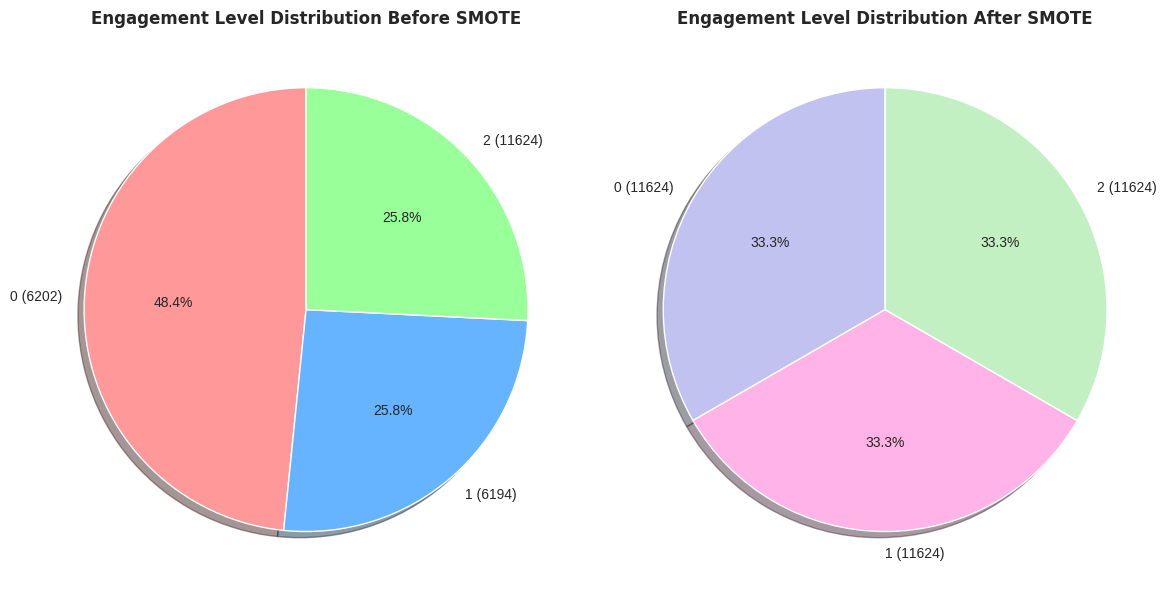

In [66]:
import matplotlib.pyplot as plt
from collections import Counter
from imblearn.over_sampling import SMOTE

# Assuming y_train is your original target variable representing engagement levels
# Example: y_train = your_dataset['engagement_level']

# Apply SMOTE to your training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Calculate the class proportions
original_counts = Counter(y_train)  # Original class counts
smote_counts = Counter(y_train_resampled)  # SMOTE class counts

# Create labels for original data based on engagement levels
original_labels = [f"{label} ({original_counts[label]})" for label in sorted(original_counts)]
smote_labels = [f"{label} ({smote_counts[label]})" for label in sorted(smote_counts)]

# Define colors for the pie chart
original_colors = ['#ff9999', '#66b3ff', '#99ff99']  # Colors for low, medium, high
smote_colors = ['#c2c2f0', '#ffb3e6', '#c2f0c2']  # Different palette for SMOTE

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Pie chart for original data
axs[0].pie(original_counts.values(), labels=original_labels, autopct='%1.1f%%',
            shadow=True, startangle=90, textprops={'fontsize': 10, 'fontname': 'Liberation Sans'},
            colors=original_colors)
axs[0].set_title("Engagement Level Distribution Before SMOTE", fontsize=12, fontweight='bold')

# Pie chart for SMOTE data
axs[1].pie(smote_counts.values(), labels=smote_labels, autopct='%1.1f%%',
            shadow=True, startangle=90, textprops={'fontsize': 10, 'fontname': 'Liberation Sans'},
            colors=smote_colors)
axs[1].set_title("Engagement Level Distribution After SMOTE", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [67]:
# Calculate the mode of the target variable after resampling
y_central = y.mode()[0]
y_central

2

In [68]:
y_base = np.full(y_train.shape, y_central)
y1_base = np.full(y_val.shape, y_central)
y2_base = np.full(y_test.shape, y_central)

In [69]:
from sklearn.metrics import accuracy_score

# Calculate accuracy score
accuracy_train = accuracy_score(y_train, y_base)
accuracy_val = accuracy_score(y_val, y1_base)
accuracy_test = accuracy_score(y_test, y2_base)

# Display the accuracy score
print("Accuracy for Training Set:", accuracy_train)
print("Accuracy for Validation Set:", accuracy_val)
print("Accuracy for Test Set:", accuracy_test)

Accuracy for Training Set: 0.4839300582847627
Accuracy for Validation Set: 0.48395154240039967
Accuracy for Test Set: 0.48395154240039967


In [70]:
from sklearn.linear_model import LogisticRegression

# Create a Logistic Regression model
logistic_model = LogisticRegression()

In [71]:
# Train the model on the training data
logistic_model.fit(X_train_resampled, y_train_resampled)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [72]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Predict on the validation set
y_val_pred = logistic_model.predict(X_val)
y_val_prob = logistic_model.predict_proba(X_val)[:, 1] if len(logistic_model.classes_) == 2 else None

# Predict on the test set
y_test_pred = logistic_model.predict(X_test)
y_test_prob = logistic_model.predict_proba(X_test)[:, 1] if len(logistic_model.classes_) == 2 else None

# Evaluate on the validation set
accuracy_val = accuracy_score(y_val, y_val_pred)
precision_val = precision_score(y_val, y_val_pred, average='weighted')
recall_val = recall_score(y_val, y_val_pred, average='weighted')
f1_val = f1_score(y_val, y_val_pred, average='weighted')

# ROC AUC score for binary classification (validation set)
roc_auc_val = roc_auc_score(y_val, y_val_prob) if y_val_prob is not None else "N/A (ROC AUC is for binary classification)"

# Evaluate on the test set
accuracy_test = accuracy_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred, average='weighted')
recall_test = recall_score(y_test, y_test_pred, average='weighted')
f1_test = f1_score(y_test, y_test_pred, average='weighted')

# ROC AUC score for binary classification (test set)
roc_auc_test = roc_auc_score(y_test, y_test_prob) if y_test_prob is not None else "N/A (ROC AUC is for binary classification)"

# Print validation set metrics
print("Validation Set Metrics:")
print("Accuracy:", accuracy_val)
print("Precision:", precision_val)
print("Recall:", recall_val)
print("F1 Score:", f1_val)
print("ROC AUC Score:", roc_auc_val)

# Print test set metrics
print("\nTest Set Metrics:")
print("Accuracy:", accuracy_test)
print("Precision:", precision_test)
print("Recall:", recall_test)
print("F1 Score:", f1_test)
print("ROC AUC Score:", roc_auc_test)

Validation Set Metrics:
Accuracy: 0.7816910203571875
Precision: 0.7910613605992455
Recall: 0.7816910203571875
F1 Score: 0.7812294186800296
ROC AUC Score: N/A (ROC AUC is for binary classification)

Test Set Metrics:
Accuracy: 0.7869364306232047
Precision: 0.7972793503685176
Recall: 0.7869364306232047
F1 Score: 0.7866500884735015
ROC AUC Score: N/A (ROC AUC is for binary classification)


In [73]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

# Assuming `logistic_model` is already fitted and you have the classes
n_classes = len(logistic_model.classes_)

# Binarize the labels for ROC AUC calculation (one-vs-rest)
y_val_binarized = label_binarize(y_val, classes=logistic_model.classes_)
y_test_binarized = label_binarize(y_test, classes=logistic_model.classes_)

# Get predicted probabilities for each class
y_val_proba = logistic_model.predict_proba(X_val)
y_test_proba = logistic_model.predict_proba(X_test)

# Calculate ROC AUC (macro-average)
val_roc_auc_macro = roc_auc_score(y_val_binarized, y_val_proba, average='macro', multi_class='ovr')
test_roc_auc_macro = roc_auc_score(y_test_binarized, y_test_proba, average='macro', multi_class='ovr')

# Calculate ROC AUC (micro-average)
val_roc_auc_micro = roc_auc_score(y_val_binarized, y_val_proba, average='micro', multi_class='ovr')
test_roc_auc_micro = roc_auc_score(y_test_binarized, y_test_proba, average='micro', multi_class='ovr')

print("Validation ROC AUC Macro-Average:", val_roc_auc_macro)
print("Validation ROC AUC Micro-Average:", val_roc_auc_micro)

print("\nTest ROC AUC Macro-Average:", test_roc_auc_macro)
print("Test ROC AUC Micro-Average:", test_roc_auc_micro)

Validation ROC AUC Macro-Average: 0.9118739433421047
Validation ROC AUC Micro-Average: 0.9118653031975316

Test ROC AUC Macro-Average: 0.9114716381401985
Test ROC AUC Micro-Average: 0.9109084627758506


In [74]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Define the parameter grid to search
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Regularization parameter
    'penalty': ['l1', 'l2'],  # Penalty term
    'solver': ['liblinear'],  # Algorithm to use for optimization
    'max_iter': [100, 200, 300],  # Maximum number of iterations
}

# Create a Logistic Regression model
logistic_regression = LogisticRegression()

# Create the GridSearchCV object
grid_search = GridSearchCV(logistic_regression, param_grid, cv=5, scoring='accuracy', verbose=1, n_jobs=-1)

# Perform grid search to find the best parameters
grid_search.fit(X_train_resampled, y_train_resampled)

# Get the best parameters
best_params = grid_search.best_params_
print("Best Parameters:", best_params)

# Get the best model
best_model = grid_search.best_estimator_

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters: {'C': 10, 'max_iter': 200, 'penalty': 'l1', 'solver': 'liblinear'}


In [75]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Evaluate the best model on the validation set
val_accuracy = best_model.score(X_val, y_val)
print("Validation Set Accuracy:", val_accuracy)

# Make predictions on the validation set
y_val_pred = best_model.predict(X_val)

# Calculate precision, recall, F1-score, and ROC AUC score for validation set
val_precision = precision_score(y_val, y_val_pred, average='weighted')  # Use 'weighted' for multiclass
val_recall = recall_score(y_val, y_val_pred, average='weighted')        # Use 'weighted' for multiclass
val_f1 = f1_score(y_val, y_val_pred, average='weighted')                # Use 'weighted' for multiclass
val_roc_auc = roc_auc_score(y_val, best_model.predict_proba(X_val)[:, 1]) if len(best_model.classes_) == 2 else "N/A for multiclass"

print("Validation Precision:", val_precision)
print("Validation Recall:", val_recall)
print("Validation F1-score:", val_f1)
print("Validation ROC AUC score:", val_roc_auc)

# Evaluate the best model on the test set
test_accuracy = best_model.score(X_test, y_test)
print("\nTest Set Accuracy:", test_accuracy)

# Make predictions on the test set
y_test_pred = best_model.predict(X_test)

# Calculate precision, recall, F1-score, and ROC AUC score for test set
test_precision = precision_score(y_test, y_test_pred, average='weighted')  # Use 'weighted' for multiclass
test_recall = recall_score(y_test, y_test_pred, average='weighted')        # Use 'weighted' for multiclass
test_f1 = f1_score(y_test, y_test_pred, average='weighted')                # Use 'weighted' for multiclass
test_roc_auc = roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1]) if len(best_model.classes_) == 2 else "N/A for multiclass"

print("Test Precision:", test_precision)
print("Test Recall:", test_recall)
print("Test F1-score:", test_f1)
print("Test ROC AUC score:", test_roc_auc)

Validation Set Accuracy: 0.6883976520544524
Validation Precision: 0.7415108245159779
Validation Recall: 0.6883976520544524
Validation F1-score: 0.6760774749838491
Validation ROC AUC score: N/A for multiclass

Test Set Accuracy: 0.6911452479080804
Test Precision: 0.7456745245221679
Test Recall: 0.6911452479080804
Test F1-score: 0.6796818192722828
Test ROC AUC score: N/A for multiclass


In [76]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

# Assuming `best_model` is already fitted and you have the classes
n_classes = len(best_model.classes_)

# Binarize the labels for ROC AUC calculation (one-vs-rest)
y_val_binarized = label_binarize(y_val, classes=best_model.classes_)
y_test_binarized = label_binarize(y_test, classes=best_model.classes_)

# Get predicted probabilities for each class
y_val_proba = best_model.predict_proba(X_val)
y_test_proba = best_model.predict_proba(X_test)

# Calculate ROC AUC (macro-average)
val_roc_auc_macro = roc_auc_score(y_val_binarized, y_val_proba, average='macro', multi_class='ovr')
test_roc_auc_macro = roc_auc_score(y_test_binarized, y_test_proba, average='macro', multi_class='ovr')

# Calculate ROC AUC (micro-average)
val_roc_auc_micro = roc_auc_score(y_val_binarized, y_val_proba, average='micro', multi_class='ovr')
test_roc_auc_micro = roc_auc_score(y_test_binarized, y_test_proba, average='micro', multi_class='ovr')

print("Validation ROC AUC Macro-Average:", val_roc_auc_macro)
print("Validation ROC AUC Micro-Average:", val_roc_auc_micro)

print("\nTest ROC AUC Macro-Average:", test_roc_auc_macro)
print("Test ROC AUC Micro-Average:", test_roc_auc_micro)

Validation ROC AUC Macro-Average: 0.9033345088066854
Validation ROC AUC Micro-Average: 0.8768088507044908

Test ROC AUC Macro-Average: 0.9031976123333431
Test ROC AUC Micro-Average: 0.8774888632868371


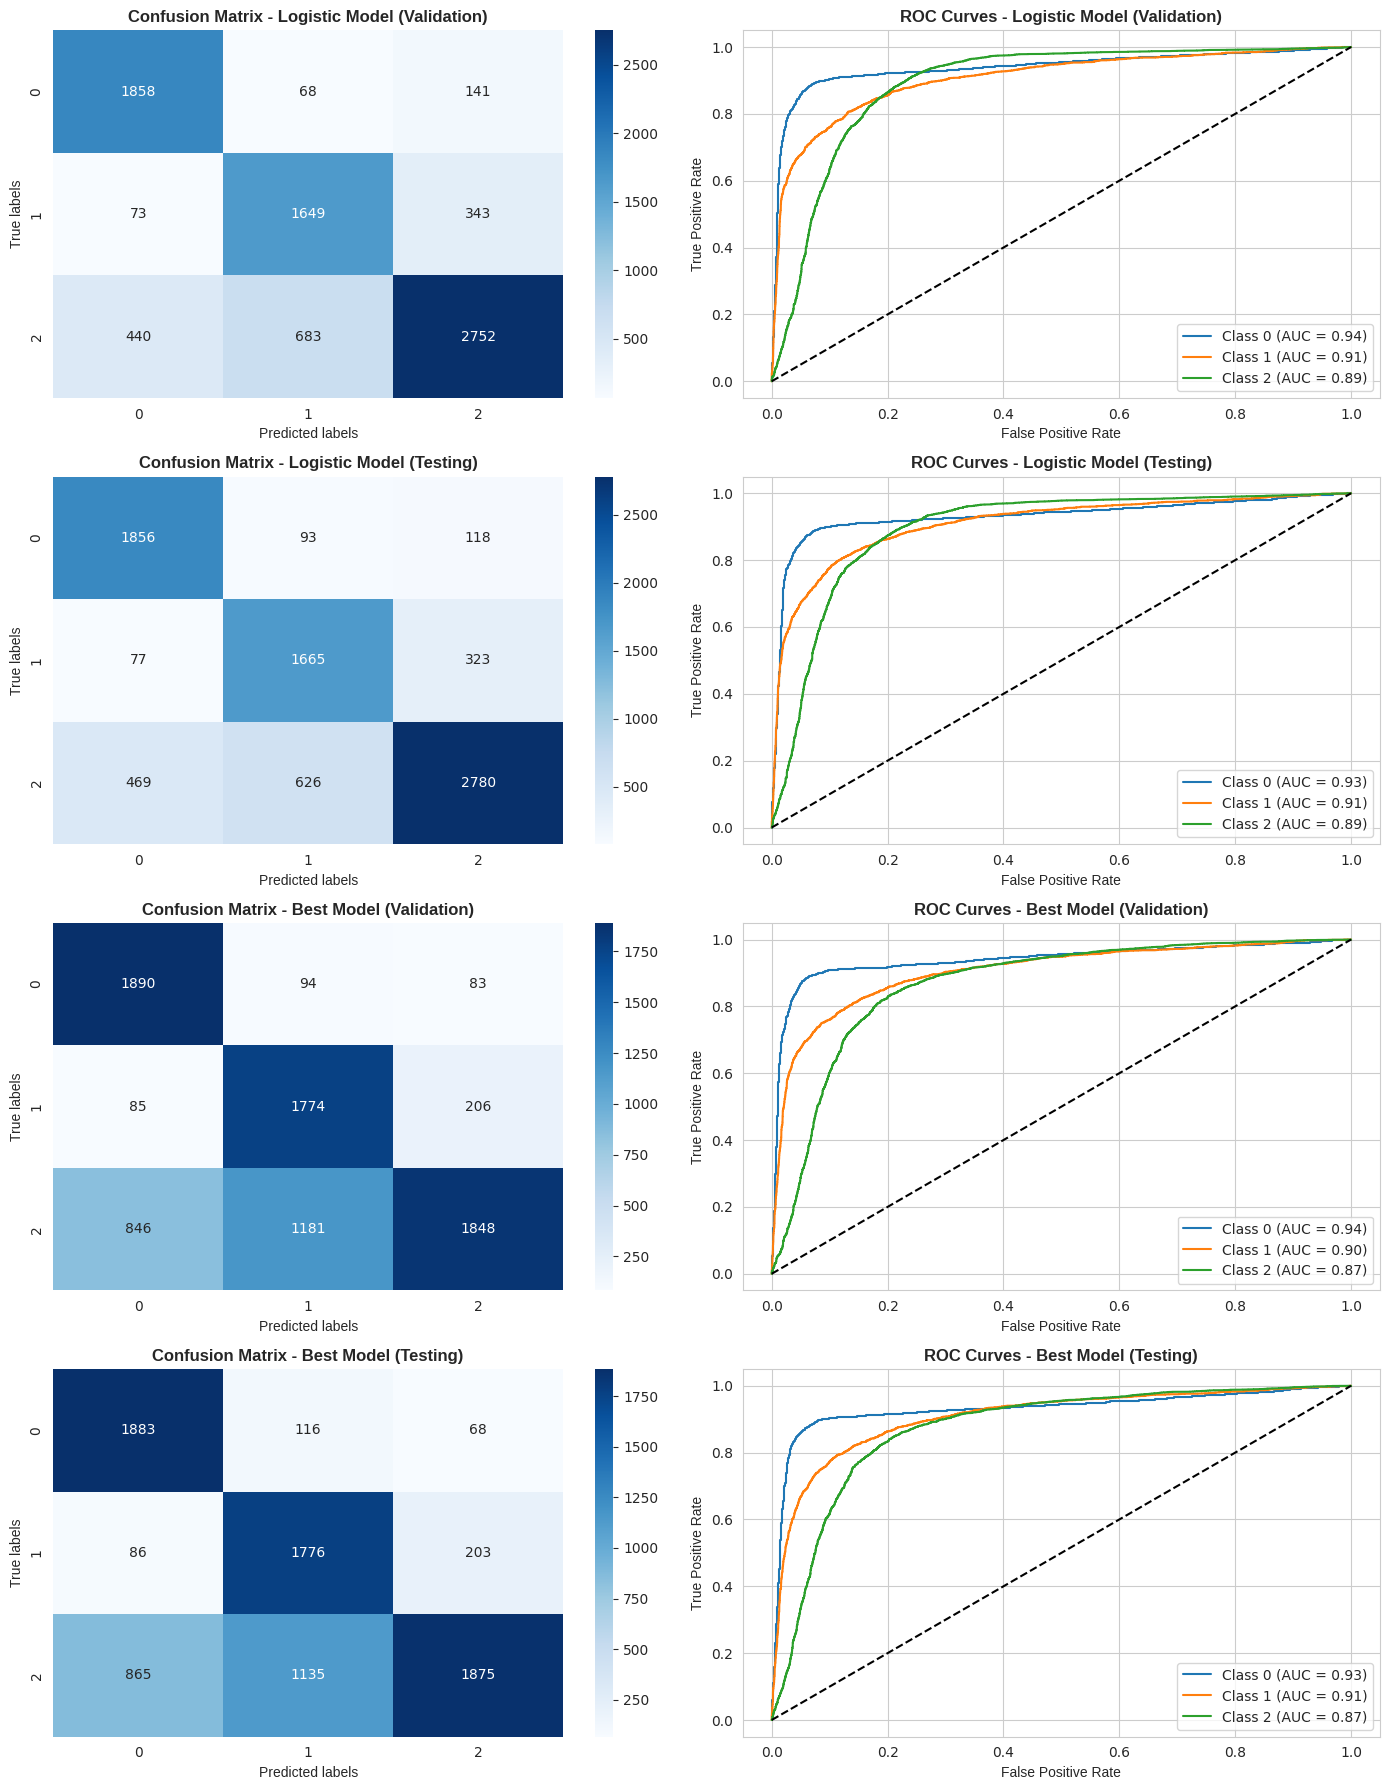

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix
from sklearn.preprocessing import label_binarize

# Function to plot confusion matrix
def plot_confusion_matrix(ax, y_true, y_pred, set_name, model_name, classes):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, cmap='Blues', fmt='g', ax=ax, xticklabels=classes, yticklabels=classes)
    ax.set_title(f'Confusion Matrix - {model_name} ({set_name})', fontname='Liberation Sans', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted labels', fontsize=10, fontname='Liberation Sans')
    ax.set_ylabel('True labels', fontsize=10, fontname='Liberation Sans')

# Function to plot ROC curves for multiclass classification
def plot_multiclass_roc_curve(ax, model, X, y, set_name, model_name, classes):
    # Binarize the output labels for ROC curve calculation (One-vs-Rest)
    y_binarized = label_binarize(y, classes=range(len(classes)))
    y_pred_proba = model.predict_proba(X)

    for i, class_name in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_binarized[:, i], y_pred_proba[:, i])
        auc = roc_auc_score(y_binarized[:, i], y_pred_proba[:, i])

        ax.plot(fpr, tpr, label=f'Class {class_name} (AUC = {auc:.2f})')

    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_xlabel('False Positive Rate', fontsize=10, fontname='Liberation Sans')
    ax.set_ylabel('True Positive Rate', fontsize=10, fontname='Liberation Sans')
    ax.set_title(f'ROC Curves - {model_name} ({set_name})', fontname='Liberation Sans', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right')

# List of class names (common to both models)
classes = best_model.classes_

# Create subplots (4x2 grid: one set for each model on validation and test data)
fig, axs = plt.subplots(4, 2, figsize=(14, 18))  # Adjust the figsize as needed

# Plot confusion matrix and ROC curve for logistic_model on validation set
plot_confusion_matrix(axs[0, 0], y_val, logistic_model.predict(X_val), "Validation", "Logistic Model", classes)
plot_multiclass_roc_curve(axs[0, 1], logistic_model, X_val, y_val, "Validation", "Logistic Model", classes)

# Plot confusion matrix and ROC curve for logistic_model on testing set
plot_confusion_matrix(axs[1, 0], y_test, logistic_model.predict(X_test), "Testing", "Logistic Model", classes)
plot_multiclass_roc_curve(axs[1, 1], logistic_model, X_test, y_test, "Testing", "Logistic Model", classes)

# Plot confusion matrix and ROC curve for best_model on validation set
plot_confusion_matrix(axs[2, 0], y_val, best_model.predict(X_val), "Validation", "Best Model", classes)
plot_multiclass_roc_curve(axs[2, 1], best_model, X_val, y_val, "Validation", "Best Model", classes)

# Plot confusion matrix and ROC curve for best_model on testing set
plot_confusion_matrix(axs[3, 0], y_test, best_model.predict(X_test), "Testing", "Best Model", classes)
plot_multiclass_roc_curve(axs[3, 1], best_model, X_test, y_test, "Testing", "Best Model", classes)

plt.tight_layout()
plt.show()

In [78]:
from sklearn.neighbors import KNeighborsClassifier

# Create KNN model
knn_model = KNeighborsClassifier()

In [79]:
# Fit the model on training data
knn_model.fit(X_train_resampled, y_train_resampled)

KNeighborsClassifier()

In [80]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

# Step 1: Predict on validation set
y_val_pred = knn_model.predict(X_val)

# Step 2: Calculate evaluation metrics for validation set
val_accuracy = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred, average='weighted')  # Use 'weighted' for multiclass
val_recall = recall_score(y_val, y_val_pred, average='weighted')
val_f1 = f1_score(y_val, y_val_pred, average='weighted')

# Step 3: ROC AUC Score (One-vs-Rest for multiclass)
y_val_binarized = label_binarize(y_val, classes=range(len(knn_model.classes_)))  # Binarize the labels
y_val_proba = knn_model.predict_proba(X_val)
val_roc_auc = roc_auc_score(y_val_binarized, y_val_proba, multi_class='ovr', average='weighted')

# Step 4: Print the results
print("Validation Set Metrics:")
print("Accuracy:", val_accuracy)
print("Precision:", val_precision)
print("Recall:", val_recall)
print("F1-score:", val_f1)
print("ROC AUC score (One-vs-Rest):", val_roc_auc)

Validation Set Metrics:
Accuracy: 0.7252404146371925
Precision: 0.7334659329706377
Recall: 0.7252404146371925
F1-score: 0.7247755823421446
ROC AUC score (One-vs-Rest): 0.864574630237232


In [81]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

# Step 1: Predict on test set
y_test_pred = knn_model.predict(X_test)

# Step 2: Calculate evaluation metrics for test set
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='weighted')  # Use 'weighted' for multiclass
test_recall = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

# Step 3: ROC AUC Score (One-vs-Rest for multiclass)
y_test_binarized = label_binarize(y_test, classes=range(len(knn_model.classes_)))  # Binarize the labels
y_test_proba = knn_model.predict_proba(X_test)
test_roc_auc = roc_auc_score(y_test_binarized, y_test_proba, multi_class='ovr', average='weighted')

# Step 4: Print the results
print("\nTest Set Metrics:")
print("Accuracy:", test_accuracy)
print("Precision:", test_precision)
print("Recall:", test_recall)
print("F1-score:", test_f1)
print("ROC AUC score (One-vs-Rest):", test_roc_auc)


Test Set Metrics:
Accuracy: 0.7331085300362183
Precision: 0.7409246694252406
Recall: 0.7331085300362183
F1-score: 0.7328386507334713
ROC AUC score (One-vs-Rest): 0.8693957606628815


In [82]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_neighbors': [3, 5, 7, 9],  # Number of neighbors to consider
    'weights': ['uniform', 'distance'],  # Weight function used in prediction
    'p': [1, 2]  # Power parameter for the Minkowski metric
}

# Create KNN model
knn_model = KNeighborsClassifier()

# Create the GridSearchCV object
grid_search = GridSearchCV(knn_model, param_grid, cv=5, scoring='accuracy', verbose=1, n_jobs=-1)

# Perform grid search to find the best parameters
grid_search.fit(X_train_resampled, y_train_resampled)

# Get the best parameters
best_params = grid_search.best_params_
print("Best Parameters:", best_params)

# Get the best model
best_knn_model = grid_search.best_estimator_

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters: {'n_neighbors': 7, 'p': 1, 'weights': 'distance'}


In [83]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

# Evaluate the best model on the validation set
val_accuracy = best_knn_model.score(X_val, y_val)
print("Validation Set Accuracy:", val_accuracy)

# Make predictions on the validation set
y_val_pred = best_knn_model.predict(X_val)

# Calculate precision, recall, F1-score for validation set
val_precision = precision_score(y_val, y_val_pred, average='weighted')  # Use 'weighted' for multiclass
val_recall = recall_score(y_val, y_val_pred, average='weighted')
val_f1 = f1_score(y_val, y_val_pred, average='weighted')

# ROC AUC Score (One-vs-Rest for multiclass)
y_val_binarized = label_binarize(y_val, classes=range(len(best_knn_model.classes_)))  # Binarize the labels
y_val_proba = best_knn_model.predict_proba(X_val)
val_roc_auc = roc_auc_score(y_val_binarized, y_val_proba, multi_class='ovr', average='weighted')

print("Validation Precision:", val_precision)
print("Validation Recall:", val_recall)
print("Validation F1-score:", val_f1)
print("Validation ROC AUC score (One-vs-Rest):", val_roc_auc)

# Evaluate the best model on the test set
test_accuracy = best_knn_model.score(X_test, y_test)
print("\nTest Set Accuracy:", test_accuracy)

# Make predictions on the test set
y_test_pred = best_knn_model.predict(X_test)

# Calculate precision, recall, F1-score for test set
test_precision = precision_score(y_test, y_test_pred, average='weighted')  # Use 'weighted' for multiclass
test_recall = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

# ROC AUC Score (One-vs-Rest for multiclass)
y_test_binarized = label_binarize(y_test, classes=range(len(best_knn_model.classes_)))  # Binarize the labels
y_test_proba = best_knn_model.predict_proba(X_test)
test_roc_auc = roc_auc_score(y_test_binarized, y_test_proba, multi_class='ovr', average='weighted')

print("Test Precision:", test_precision)
print("Test Recall:", test_recall)
print("Test F1-score:", test_f1)
print("Test ROC AUC score (One-vs-Rest):", test_roc_auc)

Validation Set Accuracy: 0.7683277132509054
Validation Precision: 0.7742696528962966
Validation Recall: 0.7683277132509054
Validation F1-score: 0.7682404035591806
Validation ROC AUC score (One-vs-Rest): 0.8920957374030896

Test Set Accuracy: 0.7795678781066567
Test Precision: 0.7855508303729347
Test Recall: 0.7795678781066567
Test F1-score: 0.779692585724333
Test ROC AUC score (One-vs-Rest): 0.8950699667370431


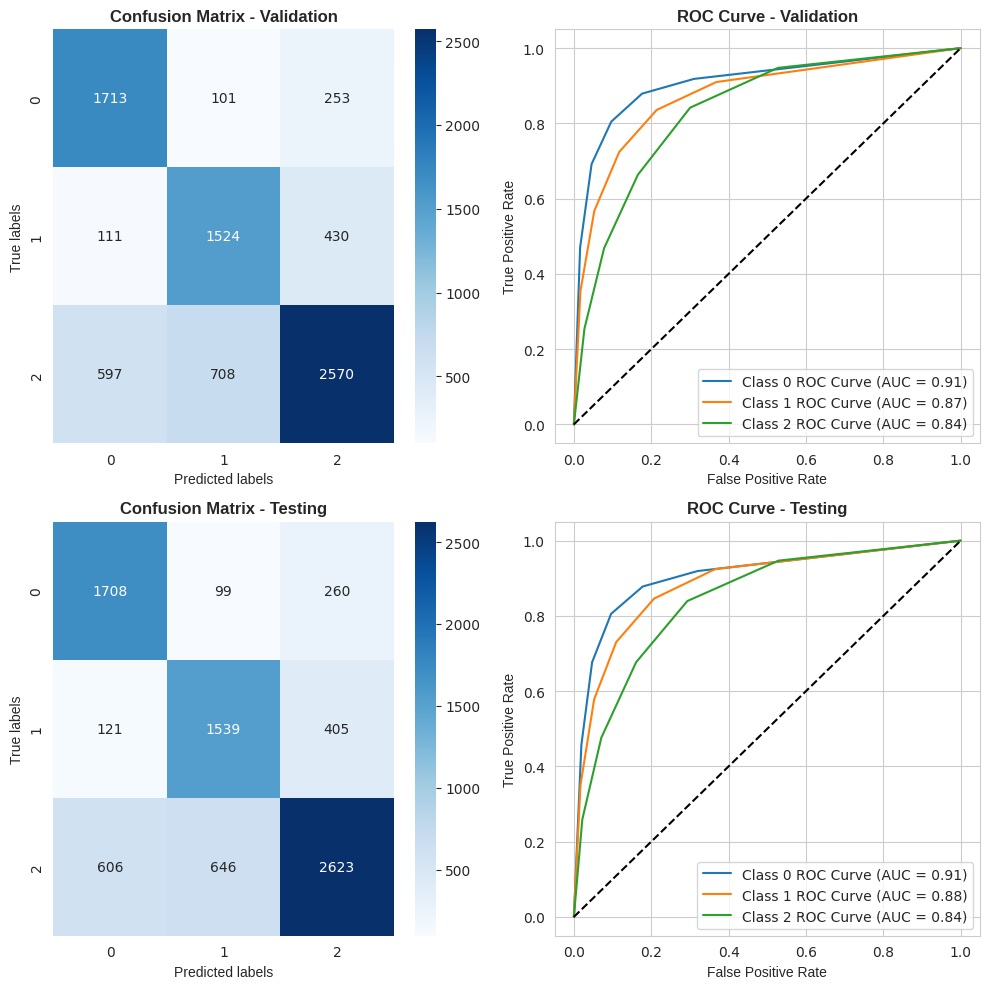

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix
from sklearn.preprocessing import label_binarize

# Fit the model on training data
knn_model.fit(X_train_resampled, y_train_resampled)

# Function to plot confusion matrix
def plot_confusion_matrix(ax, y_true, y_pred, set_name):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, cmap='Blues', fmt='g', ax=ax)
    ax.set_title(f'Confusion Matrix - {set_name}', fontname='Liberation Sans', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted labels', fontsize=10, fontname='Liberation Sans')
    ax.set_ylabel('True labels', fontsize=10, fontname='Liberation Sans')

# Function to plot ROC curve for multiclass
def plot_roc_curve(ax, model, X, y, set_name):
    y_binarized = label_binarize(y, classes=range(len(model.classes_)))  # Binarize the labels
    y_proba = model.predict_proba(X)

    # Initialize plot
    for i in range(y_binarized.shape[1]):
        fpr, tpr, _ = roc_curve(y_binarized[:, i], y_proba[:, i])
        auc = roc_auc_score(y_binarized[:, i], y_proba[:, i])
        ax.plot(fpr, tpr, label='Class {} ROC Curve (AUC = {:.2f})'.format(i, auc))

    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_xlabel('False Positive Rate', fontsize=10, fontname='Liberation Sans')
    ax.set_ylabel('True Positive Rate', fontsize=10, fontname='Liberation Sans')
    ax.set_title(f'ROC Curve - {set_name}', fontname='Liberation Sans', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right')

# Create subplots
fig, axs = plt.subplots(2, 2, figsize=(10, 10))  # Adjust the figsize as needed

# Plot confusion matrix and ROC curve for validation set
plot_confusion_matrix(axs[0, 0], y_val, knn_model.predict(X_val), "Validation")
plot_roc_curve(axs[0, 1], knn_model, X_val, y_val, "Validation")

# Plot confusion matrix and ROC curve for testing set
plot_confusion_matrix(axs[1, 0], y_test, knn_model.predict(X_test), "Testing")
plot_roc_curve(axs[1, 1], knn_model, X_test, y_test, "Testing")

plt.tight_layout()
plt.show()

In [85]:
from sklearn.ensemble import RandomForestClassifier

# Define the Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

In [86]:
# Train the Random Forest Classifier on the training data
rf_classifier.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier(random_state=42)

In [87]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

# Predict on the validation set
y_val_pred = rf_classifier.predict(X_val)

# Calculate evaluation metrics for validation set
val_accuracy = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred, average='weighted')  # Use 'weighted' to account for class imbalance
val_recall = recall_score(y_val, y_val_pred, average='weighted')  # Use 'weighted' for multiclass
val_f1 = f1_score(y_val, y_val_pred, average='weighted')  # Use 'weighted' for multiclass

# For ROC AUC, we need to binarize the labels for multiclass
y_val_binarized = label_binarize(y_val, classes=rf_classifier.classes_)
y_val_proba = rf_classifier.predict_proba(X_val)

# Calculate the ROC AUC score using the OvR (One-vs-Rest) approach
val_roc_auc = roc_auc_score(y_val_binarized, y_val_proba, average='weighted', multi_class='ovr')

print("Validation Set Metrics:")
print("Accuracy:", val_accuracy)
print("Precision:", val_precision)
print("Recall:", val_recall)
print("F1-score:", val_f1)
print("ROC AUC score:", val_roc_auc)

Validation Set Metrics:
Accuracy: 0.9129511677282378
Precision: 0.9128969583786363
Recall: 0.9129511677282378
F1-score: 0.9128569630152187
ROC AUC score: 0.9402886794144856


In [88]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

# Predict on the test set
y_test_pred = rf_classifier.predict(X_test)

# Calculate evaluation metrics for test set
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='weighted')  # Use 'weighted' for multiclass
test_recall = recall_score(y_test, y_test_pred, average='weighted')  # Use 'weighted' for multiclass
test_f1 = f1_score(y_test, y_test_pred, average='weighted')  # Use 'weighted' for multiclass

# For ROC AUC, we need to binarize the labels for multiclass
y_test_binarized = label_binarize(y_test, classes=rf_classifier.classes_)
y_test_proba = rf_classifier.predict_proba(X_test)

# Calculate the ROC AUC score using the OvR (One-vs-Rest) approach
test_roc_auc = roc_auc_score(y_test_binarized, y_test_proba, average='weighted', multi_class='ovr')

print("\nTest Set Metrics:")
print("Accuracy:", test_accuracy)
print("Precision:", test_precision)
print("Recall:", test_recall)
print("F1-score:", test_f1)
print("ROC AUC score:", test_roc_auc)


Test Set Metrics:
Accuracy: 0.9112026976395654
Precision: 0.9111041116725411
Recall: 0.9112026976395654
F1-score: 0.9111160678680345
ROC AUC score: 0.9439698589370755


In [89]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define the parameter search space
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

# Create Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=42)

# Create RandomizedSearchCV object
random_search = RandomizedSearchCV(
    estimator=rf_classifier,
    param_distributions=param_dist,
    n_iter=20,  # Number of random configurations to try
    cv=5,       # Cross-validation folds
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

# Perform Randomized Search
random_search.fit(X_train_resampled, y_train_resampled)

# Get the best parameters and model
best_params = random_search.best_params_
print("Best Parameters:", best_params)

best_rf_model = random_search.best_estimator_

Best Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 40}


In [90]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Evaluate the best model on the validation set
val_accuracy = best_rf_model.score(X_val, y_val)
print("Validation Set Accuracy:", val_accuracy)

# Make predictions on the validation set
y_val_pred = best_rf_model.predict(X_val)

# Calculate precision, recall, F1-score for multiclass
val_precision = precision_score(y_val, y_val_pred, average='weighted')  # For multiclass
val_recall = recall_score(y_val, y_val_pred, average='weighted')        # For multiclass
val_f1 = f1_score(y_val, y_val_pred, average='weighted')                # For multiclass

# Calculate ROC AUC score for multiclass (one-vs-rest)
val_roc_auc = roc_auc_score(y_val, best_rf_model.predict_proba(X_val), multi_class='ovr', average='weighted')

print("Validation Precision:", val_precision)
print("Validation Recall:", val_recall)
print("Validation F1-score:", val_f1)
print("Validation ROC AUC score:", val_roc_auc)

# Evaluate the best model on the test set
test_accuracy = best_rf_model.score(X_test, y_test)
print("\nTest Set Accuracy:", test_accuracy)

# Make predictions on the test set
y_test_pred = best_rf_model.predict(X_test)

# Calculate precision, recall, F1-score for multiclass
test_precision = precision_score(y_test, y_test_pred, average='weighted')  # For multiclass
test_recall = recall_score(y_test, y_test_pred, average='weighted')        # For multiclass
test_f1 = f1_score(y_test, y_test_pred, average='weighted')                # For multiclass

# Calculate ROC AUC score for multiclass (one-vs-rest)
test_roc_auc = roc_auc_score(y_test, best_rf_model.predict_proba(X_test), multi_class='ovr', average='weighted')

print("Test Precision:", test_precision)
print("Test Recall:", test_recall)
print("Test F1-score:", test_f1)
print("Test ROC AUC score:", test_roc_auc)

Validation Set Accuracy: 0.9123267141251405
Validation Precision: 0.9122758847191139
Validation Recall: 0.9123267141251405
Validation F1-score: 0.9122200920561928
Validation ROC AUC score: 0.9406321450117375

Test Set Accuracy: 0.9123267141251405
Test Precision: 0.9122152435563765
Test Recall: 0.9123267141251405
Test F1-score: 0.9122149544683498
Test ROC AUC score: 0.9438822050697476


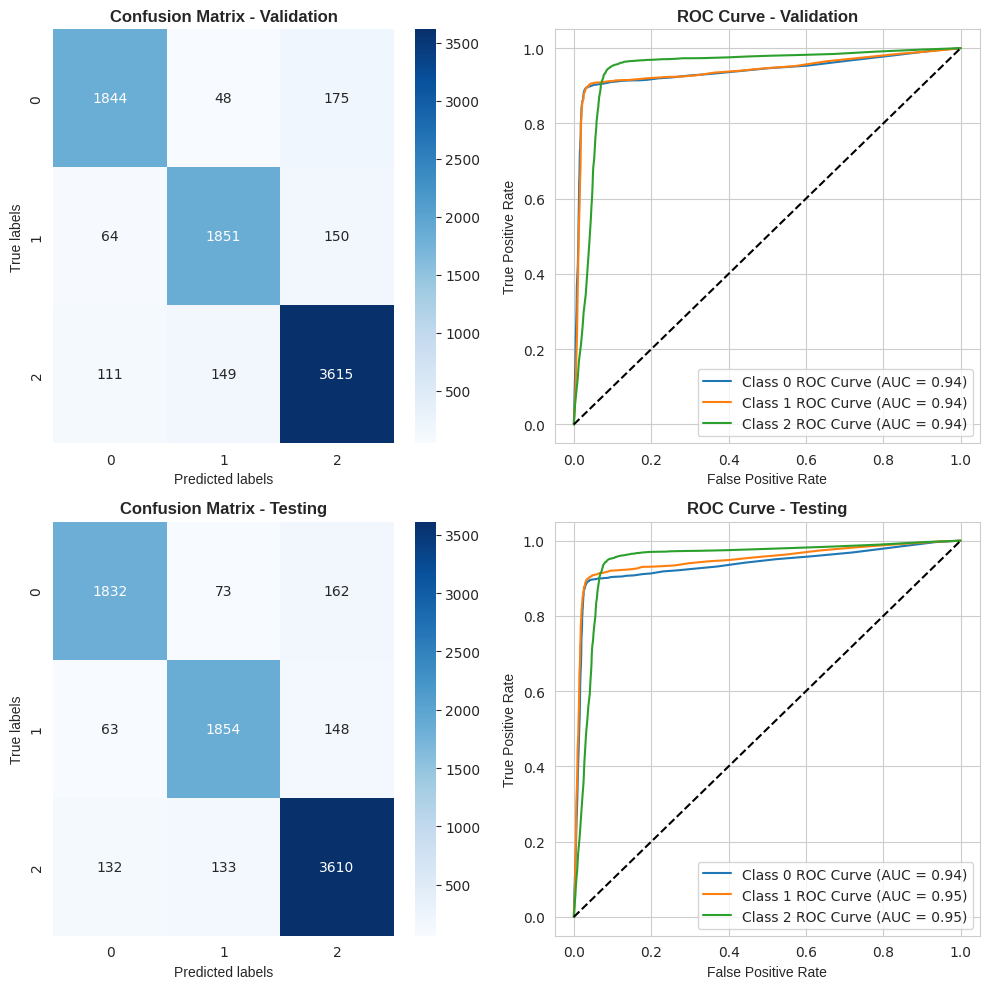

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix
from sklearn.preprocessing import label_binarize

# Fit the Random Forest model on training data
rf_classifier.fit(X_train_resampled, y_train_resampled)

# Function to plot confusion matrix
def plot_confusion_matrix(ax, y_true, y_pred, set_name):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, cmap='Blues', fmt='g', ax=ax)
    ax.set_title(f'Confusion Matrix - {set_name}', fontname='Liberation Sans', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted labels', fontsize=10, fontname='Liberation Sans')
    ax.set_ylabel('True labels', fontsize=10, fontname='Liberation Sans')

# Function to plot ROC curve for multiclass
def plot_roc_curve(ax, model, X, y, set_name):
    y_binarized = label_binarize(y, classes=range(len(model.classes_)))  # Binarize the labels
    y_proba = model.predict_proba(X)

    # Initialize plot for each class
    for i in range(y_binarized.shape[1]):
        fpr, tpr, _ = roc_curve(y_binarized[:, i], y_proba[:, i])
        auc = roc_auc_score(y_binarized[:, i], y_proba[:, i])
        ax.plot(fpr, tpr, label='Class {} ROC Curve (AUC = {:.2f})'.format(i, auc))

    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_xlabel('False Positive Rate', fontsize=10, fontname='Liberation Sans')
    ax.set_ylabel('True Positive Rate', fontsize=10, fontname='Liberation Sans')
    ax.set_title(f'ROC Curve - {set_name}', fontname='Liberation Sans', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right')

# Create subplots
fig, axs = plt.subplots(2, 2, figsize=(10, 10))  # Adjust the figsize as needed

# Plot confusion matrix and ROC curve for validation set
plot_confusion_matrix(axs[0, 0], y_val, rf_classifier.predict(X_val), "Validation")
plot_roc_curve(axs[0, 1], rf_classifier, X_val, y_val, "Validation")

# Plot confusion matrix and ROC curve for testing set
plot_confusion_matrix(axs[1, 0], y_test, rf_classifier.predict(X_test), "Testing")
plot_roc_curve(axs[1, 1], rf_classifier, X_test, y_test, "Testing")

plt.tight_layout()
plt.show()

In [92]:
from sklearn.model_selection import StratifiedKFold

# Initialize Stratified K-Fold
skf = StratifiedKFold(n_splits=10)

In [93]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# Define KNN hyperparameter grid
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]  # 1 for Manhattan, 2 for Euclidean
}

# Create KNN model and perform grid search
knn_model = KNeighborsClassifier()
knn_grid = GridSearchCV(knn_model, knn_param_grid, cv=skf, scoring='f1_weighted')
knn_grid.fit(X_train_resampled, y_train_resampled)

# Best KNN model
knn_best_model = knn_grid.best_estimator_
print(f"Best KNN Model: {knn_best_model}")

Best KNN Model: KNeighborsClassifier(n_neighbors=7, p=1, weights='distance')


In [94]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV

# Define refined Logistic Regression hyperparameter grid
logreg_param_grid = {
    'penalty': ['l1', 'l2'],
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga'],
    'class_weight': [None, 'balanced'],
    'tol': [1e-4, 1e-3, 1e-2]
}

# Use RandomizedSearchCV with fewer iterations
logreg_model = LogisticRegression(max_iter=10000, warm_start=True)
logreg_random = RandomizedSearchCV(logreg_model, logreg_param_grid, cv=3, n_iter=20, scoring='f1_weighted', n_jobs=-1)
logreg_random.fit(X_train_resampled, y_train_resampled)

# Best Logistic Regression model
logreg_best_model = logreg_random.best_estimator_
print(f"Best Logistic Regression Model: {logreg_best_model}")

Best Logistic Regression Model: LogisticRegression(C=0.1, class_weight='balanced', max_iter=10000, penalty='l1',
                   solver='saga', warm_start=True)


In [95]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Define Random Forest hyperparameter distribution
rf_param_dist = {
    'n_estimators': randint(50, 200),
    'max_depth': randint(10, 50),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 4),
    'bootstrap': [True, False]
}

# Create Random Forest model and perform randomized search
rf_model = RandomForestClassifier(random_state=42)
rf_random = RandomizedSearchCV(rf_model, rf_param_dist, n_iter=50, cv=skf, scoring='f1_weighted', random_state=42)
rf_random.fit(X_train_resampled, y_train_resampled)

# Best Random Forest model
rf_best_model = rf_random.best_estimator_
print(f"Best Random Forest Model: {rf_best_model}")

Best Random Forest Model: RandomForestClassifier(bootstrap=False, max_depth=46, min_samples_split=4,
                       n_estimators=108, random_state=42)


In [96]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import StratifiedKFold
import numpy as np

# Initialize Stratified K-Fold
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# To store metrics for each model
logreg_accuracies, logreg_f1_scores, logreg_precisions, logreg_recalls = [], [], [], []
knn_accuracies, knn_f1_scores, knn_precisions, knn_recalls = [], [], [], []
rf_accuracies, rf_f1_scores, rf_precisions, rf_recalls = [], [], [], []

# Initialize variables to store the best results
best_logreg_result = {'accuracy': 0, 'f1': 0, 'precision': 0, 'recall': 0}
best_knn_result = {'accuracy': 0, 'f1': 0, 'precision': 0, 'recall': 0}
best_rf_result = {'accuracy': 0, 'f1': 0, 'precision': 0, 'recall': 0}

# Loop through each fold
for fold_index, (train_index, val_index) in enumerate(skf.split(X, y)):
    print(f"========================================================")
    print(f"Starting with fold: {fold_index + 1}/{10}")

    # Splitting the data into training and validation sets
    train_X, test_X = X.iloc[train_index].copy(), X.iloc[val_index].copy()
    train_y, test_y = y[train_index].copy(), y[val_index].copy()

    # Apply SMOTE to the training set
    smote = SMOTE(random_state=42)
    train_X_resampled, train_y_resampled = smote.fit_resample(train_X, train_y)

    # Logistic Regression
    logreg_model = logreg_best_model  # Use the best-tuned Logistic Regression model
    logreg_model.fit(train_X_resampled, train_y_resampled)
    logreg_preds = logreg_model.predict(test_X)

    logreg_acc = accuracy_score(test_y, logreg_preds)
    logreg_f1 = f1_score(test_y, logreg_preds, average='weighted')
    logreg_precision = precision_score(test_y, logreg_preds, average='weighted')
    logreg_recall = recall_score(test_y, logreg_preds, average='weighted')

    logreg_accuracies.append(logreg_acc)
    logreg_f1_scores.append(logreg_f1)
    logreg_precisions.append(logreg_precision)
    logreg_recalls.append(logreg_recall)

    # Update best Logistic Regression result if this fold is better
    if logreg_acc > best_logreg_result['accuracy']:
        best_logreg_result = {'accuracy': logreg_acc, 'f1': logreg_f1, 'precision': logreg_precision, 'recall': logreg_recall}

    # KNN
    knn_model = knn_best_model  # Use the best-tuned KNN model
    knn_model.fit(train_X_resampled, train_y_resampled)
    knn_preds = knn_model.predict(test_X)

    knn_acc = accuracy_score(test_y, knn_preds)
    knn_f1 = f1_score(test_y, knn_preds, average='weighted')
    knn_precision = precision_score(test_y, knn_preds, average='weighted')
    knn_recall = recall_score(test_y, knn_preds, average='weighted')

    knn_accuracies.append(knn_acc)
    knn_f1_scores.append(knn_f1)
    knn_precisions.append(knn_precision)
    knn_recalls.append(knn_recall)

    # Update best KNN result if this fold is better
    if knn_acc > best_knn_result['accuracy']:
        best_knn_result = {'accuracy': knn_acc, 'f1': knn_f1, 'precision': knn_precision, 'recall': knn_recall}

    # Random Forest Classifier
    rf_model = rf_best_model  # Use the best-tuned Random Forest model
    rf_model.fit(train_X_resampled, train_y_resampled)
    rf_preds = rf_model.predict(test_X)

    rf_acc = accuracy_score(test_y, rf_preds)
    rf_f1 = f1_score(test_y, rf_preds, average='weighted')
    rf_precision = precision_score(test_y, rf_preds, average='weighted')
    rf_recall = recall_score(test_y, rf_preds, average='weighted')

    rf_accuracies.append(rf_acc)
    rf_f1_scores.append(rf_f1)
    rf_precisions.append(rf_precision)
    rf_recalls.append(rf_recall)

    # Update best Random Forest result if this fold is better
    if rf_acc > best_rf_result['accuracy']:
        best_rf_result = {'accuracy': rf_acc, 'f1': rf_f1, 'precision': rf_precision, 'recall': rf_recall}

    # Print fold results
    print(f"Logistic Regression - Accuracy: {logreg_acc:.4f}, F1: {logreg_f1:.4f}, Precision: {logreg_precision:.4f}, Recall: {logreg_recall:.4f}")
    print(f"KNN - Accuracy: {knn_acc:.4f}, F1: {knn_f1:.4f}, Precision: {knn_precision:.4f}, Recall: {knn_recall:.4f}")
    print(f"Random Forest - Accuracy: {rf_acc:.4f}, F1: {rf_f1:.4f}, Precision: {rf_precision:.4f}, Recall: {rf_recall:.4f}")

# Final summary
print("========================================================")
print("Logistic Regression - Avg Accuracy: {:.4f}, Avg F1: {:.4f}, Avg Precision: {:.4f}, Avg Recall: {:.4f}".format(
    np.mean(logreg_accuracies), np.mean(logreg_f1_scores), np.mean(logreg_precisions), np.mean(logreg_recalls)))
print("KNN - Avg Accuracy: {:.4f}, Avg F1: {:.4f}, Avg Precision: {:.4f}, Avg Recall: {:.4f}".format(
    np.mean(knn_accuracies), np.mean(knn_f1_scores), np.mean(knn_precisions), np.mean(knn_recalls)))
print("Random Forest - Avg Accuracy: {:.4f}, Avg F1: {:.4f}, Avg Precision: {:.4f}, Avg Recall: {:.4f}".format(
    np.mean(rf_accuracies), np.mean(rf_f1_scores), np.mean(rf_precisions), np.mean(rf_recalls)))

# Best fold results
print("========================================================")
print("Best Logistic Regression - Accuracy: {:.4f}, F1: {:.4f}, Precision: {:.4f}, Recall: {:.4f}".format(
    best_logreg_result['accuracy'], best_logreg_result['f1'], best_logreg_result['precision'], best_logreg_result['recall']))
print("Best KNN - Accuracy: {:.4f}, F1: {:.4f}, Precision: {:.4f}, Recall: {:.4f}".format(
    best_knn_result['accuracy'], best_knn_result['f1'], best_knn_result['precision'], best_knn_result['recall']))
print("Best Random Forest - Accuracy: {:.4f}, F1: {:.4f}, Precision: {:.4f}, Recall: {:.4f}".format(
    best_rf_result['accuracy'], best_rf_result['f1'], best_rf_result['precision'], best_rf_result['recall']))

Starting with fold: 1/10
Logistic Regression - Accuracy: 0.7920, F1: 0.7916, Precision: 0.8012, Recall: 0.7920
KNN - Accuracy: 0.7892, F1: 0.7894, Precision: 0.7940, Recall: 0.7892
Random Forest - Accuracy: 0.9183, F1: 0.9182, Precision: 0.9182, Recall: 0.9183
Starting with fold: 2/10
Logistic Regression - Accuracy: 0.7942, F1: 0.7937, Precision: 0.8027, Recall: 0.7942
KNN - Accuracy: 0.7922, F1: 0.7922, Precision: 0.7974, Recall: 0.7922
Random Forest - Accuracy: 0.9226, F1: 0.9224, Precision: 0.9226, Recall: 0.9226
Starting with fold: 3/10
Logistic Regression - Accuracy: 0.7887, F1: 0.7878, Precision: 0.7974, Recall: 0.7887
KNN - Accuracy: 0.7907, F1: 0.7907, Precision: 0.7975, Recall: 0.7907
Random Forest - Accuracy: 0.9198, F1: 0.9196, Precision: 0.9197, Recall: 0.9198
Starting with fold: 4/10
Logistic Regression - Accuracy: 0.7880, F1: 0.7880, Precision: 0.7986, Recall: 0.7880
KNN - Accuracy: 0.7827, F1: 0.7830, Precision: 0.7870, Recall: 0.7827
Random Forest - Accuracy: 0.9153, F1

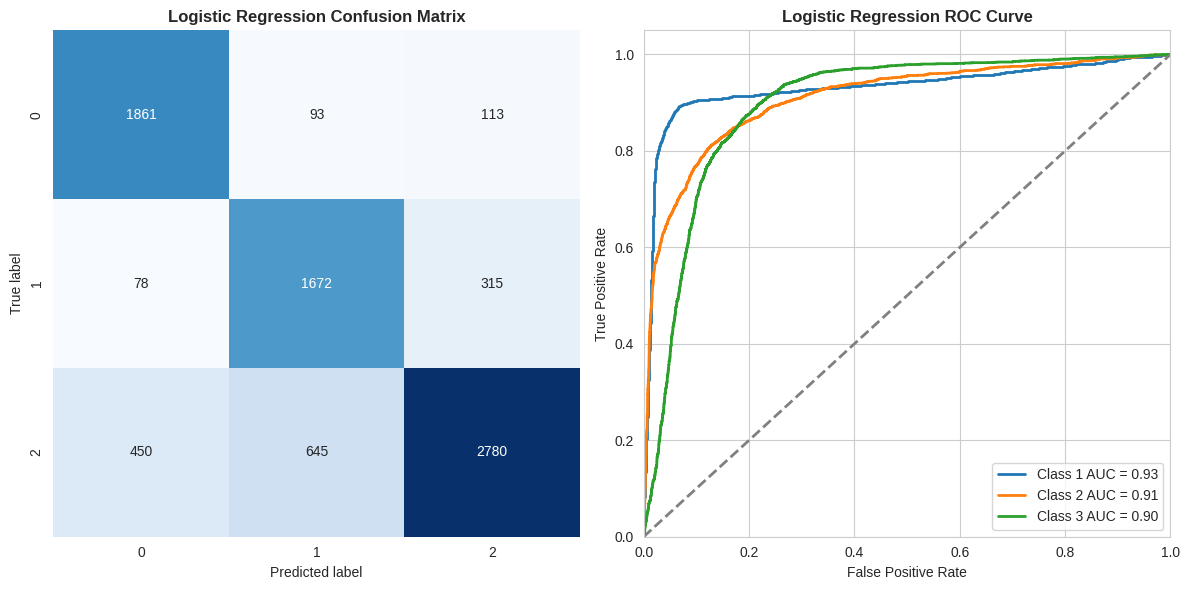

In [97]:
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

# Set font to Liberation Sans and make titles bold
rcParams['font.family'] = 'Liberation Sans'
rcParams['axes.titleweight'] = 'bold'

# Function to plot the confusion matrix
def plot_confusion_matrix(cm, title, ax):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(f'{title}', fontweight='bold')
    ax.set_ylabel('True label')
    ax.set_xlabel('Predicted label')

# Function to plot ROC curves for multiclass classification
def plot_multiclass_roc_curve(probs, model_name, y_test, n_classes, ax):
    fpr, tpr, roc_auc = dict(), dict(), dict()
    y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

    # Plot ROC curve for each class
    for j in range(n_classes):
        fpr[j], tpr[j], _ = roc_curve(y_test_bin[:, j], probs[:, j])
        roc_auc[j] = auc(fpr[j], tpr[j])
        ax.plot(fpr[j], tpr[j], lw=2, label=f'Class {j+1} AUC = {roc_auc[j]:.2f}')

    ax.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{model_name} ROC Curve', fontweight='bold')
    ax.legend(loc='lower right')

# Confusion Matrices and ROC Curves
logreg_cm = confusion_matrix(y_test, logreg_best_model.predict(X_test))
knn_cm = confusion_matrix(y_test, knn_best_model.predict(X_test))
rf_cm = confusion_matrix(y_test, rf_best_model.predict(X_test))

logreg_probs = logreg_best_model.predict_proba(X_test)
knn_probs = knn_best_model.predict_proba(X_test)
rf_probs = rf_best_model.predict_proba(X_test)

# Number of classes (assuming multiclass)
n_classes = len(np.unique(y_test))

# Plotting for Logistic Regression
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Logistic Regression Confusion Matrix
plot_confusion_matrix(logreg_cm, 'Logistic Regression Confusion Matrix', ax=axes[0])

# Logistic Regression ROC Curve
plot_multiclass_roc_curve(logreg_probs, 'Logistic Regression', y_test, n_classes, ax=axes[1])

plt.tight_layout()
plt.show()

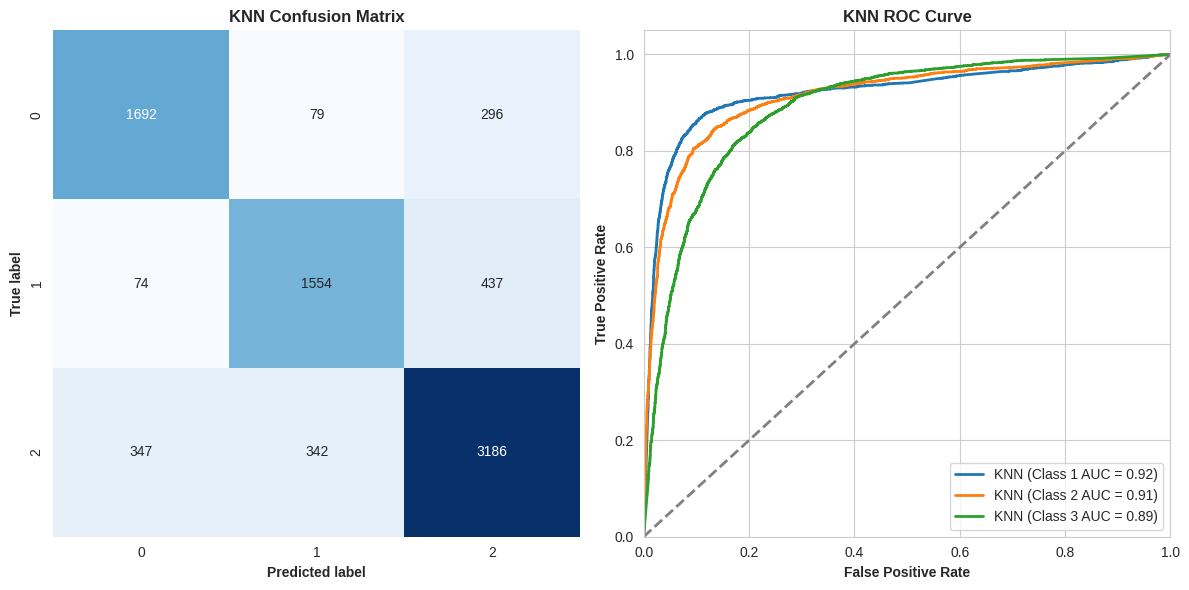

In [98]:
from sklearn.calibration import CalibratedClassifierCV
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.preprocessing import label_binarize
import numpy as np

# Calibrate the KNN model to improve probability estimates
calibrated_knn = CalibratedClassifierCV(knn_best_model, method='sigmoid')
calibrated_knn.fit(X_train_resampled, y_train_resampled)

# Predict probabilities using calibrated model
calibrated_knn_probs = calibrated_knn.predict_proba(X_test)

# Function to plot the confusion matrix
def plot_confusion_matrix(cm, title, ax):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted label', fontweight='bold')
    ax.set_ylabel('True label', fontweight='bold')

# Function to plot the ROC curve
def plot_multiclass_roc_curve(probs, model_name, y_test, n_classes, ax):
    fpr, tpr, roc_auc = dict(), dict(), dict()
    y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

    for j in range(n_classes):
        fpr[j], tpr[j], _ = roc_curve(y_test_bin[:, j], probs[:, j])
        roc_auc[j] = auc(fpr[j], tpr[j])
        ax.plot(fpr[j], tpr[j], lw=2, label=f'{model_name} (Class {j+1} AUC = {roc_auc[j]:.2f})')

    ax.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontweight='bold')
    ax.set_ylabel('True Positive Rate', fontweight='bold')
    ax.set_title(f'{model_name} ROC Curve', fontweight='bold')
    ax.legend(loc='lower right')

# Predict the confusion matrix for KNN
knn_cm = confusion_matrix(y_test, calibrated_knn.predict(X_test))

# Plotting for KNN Confusion Matrix and ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# KNN Confusion Matrix
plot_confusion_matrix(knn_cm, 'KNN Confusion Matrix', ax=axes[0])

# KNN ROC Curve (calibrated model)
plot_multiclass_roc_curve(calibrated_knn_probs, 'KNN', y_test, n_classes, ax=axes[1])

plt.tight_layout()
plt.show()

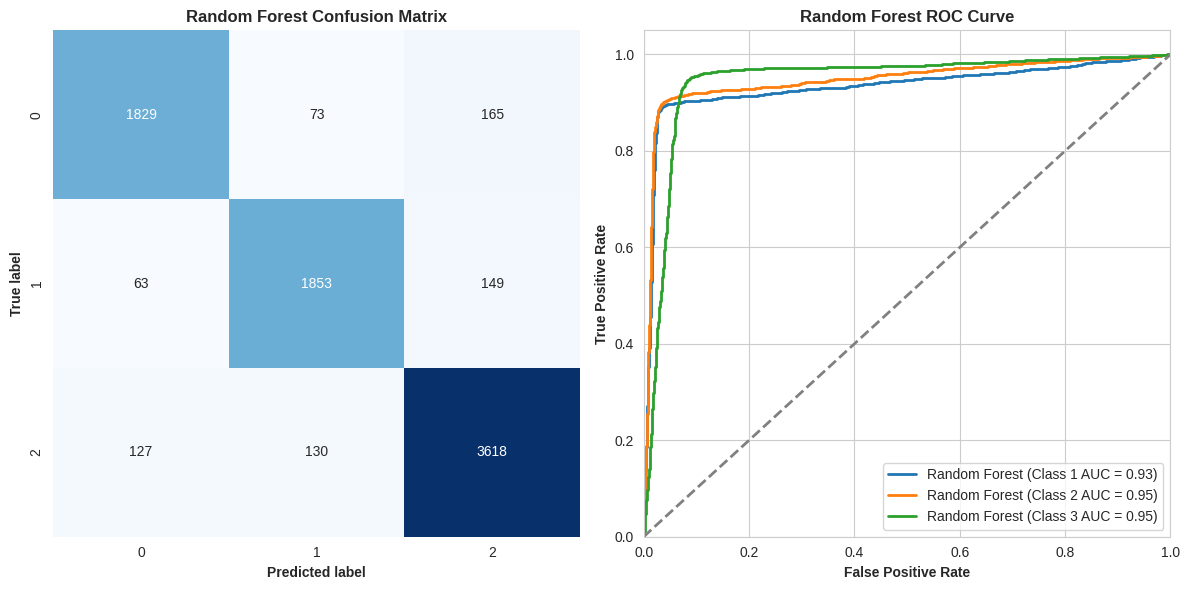

In [99]:
from sklearn.calibration import CalibratedClassifierCV

# Calibrate the Random Forest classifier
calibrated_rf = CalibratedClassifierCV(rf_best_model, method='sigmoid')
calibrated_rf.fit(X_train_resampled, y_train_resampled)

# Predict probabilities and confusion matrix using calibrated model
calibrated_rf_probs = calibrated_rf.predict_proba(X_test)
rf_cm = confusion_matrix(y_test, calibrated_rf.predict(X_test))

# Function to plot the confusion matrix
def plot_confusion_matrix(cm, title, ax):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted label', fontweight='bold')
    ax.set_ylabel('True label', fontweight='bold')

# Function to plot the ROC curve
def plot_multiclass_roc_curve(probs, model_name, y_test, n_classes, ax):
    fpr, tpr, roc_auc = dict(), dict(), dict()
    y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

    for j in range(n_classes):
        fpr[j], tpr[j], _ = roc_curve(y_test_bin[:, j], probs[0][:, j])
        roc_auc[j] = auc(fpr[j], tpr[j])
        ax.plot(fpr[j], tpr[j], lw=2, label=f'{model_name} (Class {j+1} AUC = {roc_auc[j]:.2f})')

    ax.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontweight='bold')
    ax.set_ylabel('True Positive Rate', fontweight='bold')
    ax.set_title(f'{model_name} ROC Curve', fontweight='bold')
    ax.legend(loc='lower right')

# Plotting Confusion Matrix and ROC Curve for Calibrated Random Forest
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Random Forest Confusion Matrix
plot_confusion_matrix(rf_cm, 'Random Forest Confusion Matrix', ax=axes[0])

# Random Forest ROC Curve
plot_multiclass_roc_curve([calibrated_rf_probs], 'Random Forest', y_test, n_classes, ax=axes[1])

plt.tight_layout()
plt.show()

                     Feature  Importance
2            SessionsPerWeek       0.457
3  AvgSessionDurationMinutes       0.355
4                PlayerLevel       0.053
1              PlayTimeHours       0.053
5       AchievementsUnlocked       0.046
0                        Age       0.037


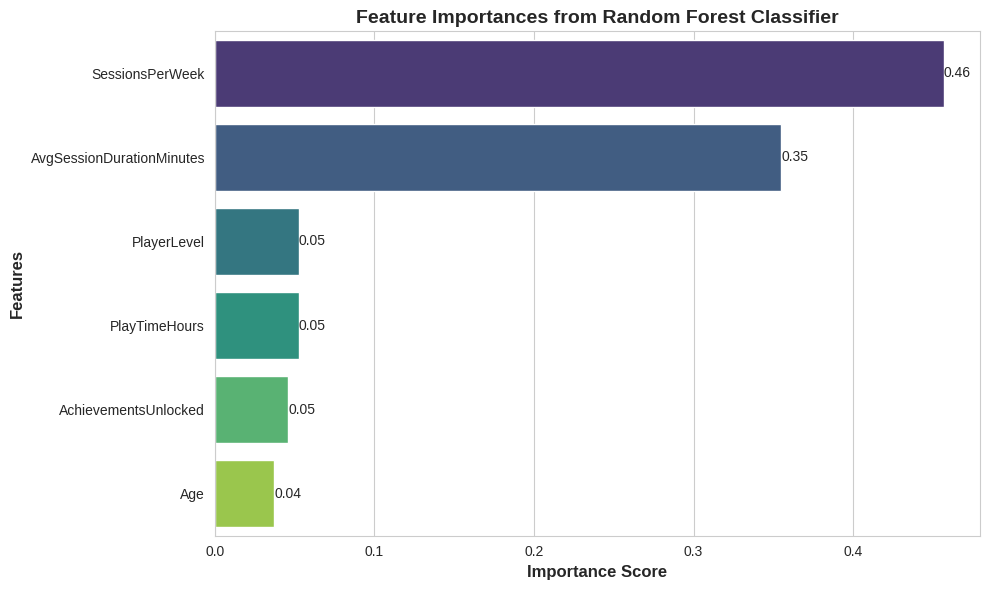

In [100]:
# Get feature importances from the Random Forest model
feature_importances = rf_best_model.feature_importances_

# Create a DataFrame to hold feature names and their importances
feature_names = X_train_resampled.columns  # Replace with the correct feature names if necessary
importances_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort the DataFrame by importance
importances_df = importances_df.sort_values(by='Importance', ascending=False)

# Print the feature importances
print(importances_df)

# Set a color palette
colors = sns.color_palette("viridis", len(importances_df))  # You can choose a different palette if you prefer

# Optionally, you can plot the feature importances with different colors
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importances_df, palette=colors)

# Add title and labels
plt.title('Feature Importances from Random Forest Classifier', fontweight='bold', fontsize=14)
plt.xlabel('Importance Score', fontweight='bold', fontsize=12)
plt.ylabel('Features', fontweight='bold', fontsize=12)

# Add value annotations to each bar
for index, value in enumerate(importances_df['Importance']):
    plt.text(value, index, f'{value:.2f}', va='center', fontsize=10)

plt.tight_layout()  # Adjust layout
plt.show()